# Stage 2 - Co-Living Compatiblity Prediction Based On Operational & Survey Data

This notebook explores a dataset downloaded from Village M's backoffice software (REOS) which comprises of tenant data living at the co-living building in the month of November 2025. Aditionally, a dataframe called responses holds survey data from this population which has personality traits, lifestyle value, living preferemces, expectations and compatability truth values to model co-living compatibility.

In [117]:
# Load packages
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Other useful packages
import gender_guesser.detector as gender
import re
import plotly.express as px
import plotly.graph_objects as go


## November 2025 Tenant Data

The dataset has been imported from Village M's backoffice (REOS software) and includes tenant data in the month of November 2025. In the subsequent chunks, this dataset is cleaned in order to merge it with compatibility survey data from the same population.

### Data Cleaning

In [2]:
# Load dataset
df = pd.read_csv(
    "/Users/user/Documents/master/semester3/Thesis/stage_2/main_nov.csv",
    sep=';',              
    encoding='utf-8',     # encoding for umlauts like ä, ö, ü
)

# Check structure
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Vorname             563 non-null    object 
 1   Nachname            563 non-null    object 
 2   Mietvertrag         564 non-null    object 
 3   Einheit             564 non-null    object 
 4   Wohnung             564 non-null    object 
 5   Lage                564 non-null    object 
 6   Objekt              564 non-null    object 
 7   Buchungspartner     0 non-null      float64
 8   Buchungspartner ID  0 non-null      float64
 9   Einzug              564 non-null    object 
 10  Auszug              564 non-null    object 
 11  E-Mail              560 non-null    object 
 12  Telefon             516 non-null    object 
 13  Geburtsdatum        531 non-null    object 
 14  Nationalität        510 non-null    object 
 15  Beruf               533 non-null    object 
dtypes: float

,Vorname,Nachname,Mietvertrag,Einheit,Wohnung,Lage,Objekt,Buchungspartner,Buchungspartner ID,Einzug,Auszug,E-Mail,Telefon,Geburtsdatum,Nationalität,Beruf
0,NaN,The Village Psw GmbH & Co.KG,R12017C201768XW,CU.31.4,CU.31,"1005,00 Euro",CU44,NaN,NaN,01.06.2025,31.05.2026,NaN,NaN,NaN,NaN,NaN
1,Aaditya,Jhinjharia,R8550C2091506W,B.02.1,B.02,"1020,00 Euro",Aufgang B,NaN,NaN,01.08.2025,30.11.2025,aadityajhinjharia@gmail.com,8588953709,18.10.2005,IND,Student
2,aairah abidhussain,syed,R9003C2015726W,D.54.1,D.54,"1110,00 Euro",Aufgang D,NaN,NaN,10.06.2025,30.06.2026,airusyed@gmail.com,'+919867281455,22.11.2006,IND,Student
3,Aaron,Vitarana,R21985C1777382W,FR.71.5,FR.71,"1335,00 EUR",FRI.63,NaN,NaN,01.01.2025,30.12.2025,aaron.vitarana@gmail.com,'+447506751992,25.03.2000,DEU,Angestellt
4,Abdallah,Afifi,R7643C2067131W,A.26.3,A.26,"975,00 EUR",Aufgang A,NaN,NaN,12.07.2025,31.07.2026,abdallahmohamedtech@gmail.com,'+201095105091,09.11.2004,EGY,Angestellt


In [3]:
# Rename columns German to English
df = df.rename(columns={
    "Vorname": "FirstName",
    "Nachname": "LastName",
    "Mietvertrag": "LeaseContract",
    "Einheit": "Unit",
    "Wohnung": "Apartment", # only unit is important here
    "Lage": "Location", # not necessary, this is actually something else in the df so remove later
    "Objekt": "Building",
    "Buchungspartner": "BookingPartner",
    "Buchungspartner ID": "BookingPartnerID",
    "Einzug": "MoveInDate",
    "Auszug": "MoveOutDate",
    "E-Mail": "Email",
    "Telefon": "Phone",
    "Geburtsdatum": "DateOfBirth",
    "Nationalität": "Nationality",  
    "Beruf": "Occupation"
})

# Drop unwanted columns
df = df.drop(
    columns=[
        "LeaseContract",
        "Location",
        "Building",
        "BookingPartner",
        "BookingPartnerID",
        "Email",
        "Phone"
    ],
    errors="ignore"
)

# Unique occupationv values & nationality values
print("Unique Occupations:", df['Occupation'].unique())
print("Unique Nationalities:", df['Nationality'].unique()) 


Unique Occupations: [nan 'Student' 'Angestellt' 'Arbeitssuchend' 'Ausbildung' 'Selbstständig'
 'Beamter']
Unique Nationalities: [nan 'IND' 'DEU' 'EGY' 'MAR' 'TZA' 'YEM' 'FRA' 'PAK' 'LBN' 'ESP' 'KAZ'
 'ROU' 'ITA' 'MEX' 'COL' 'SRB' 'POL' 'BRA' 'IRN' 'NLD' 'UKR' 'USA' 'LTU'
 'RUS' 'BIH' 'THA' 'ARG' 'NGA' 'KOR' 'HUN' 'CHL' 'TUR' 'CHN' 'TWN' 'PRT'
 'GBR' 'IDN' 'AUT' 'LUX' 'HND' 'KEN' 'BGR' 'KGZ' 'MDA' 'AFG' 'ZAF' 'AZE'
 'GRC' 'PRY' 'MMR' 'SYR' 'TJK' 'BLR' 'PER' 'GTM' 'CMR' 'ECU' 'LKA' 'IRQ'
 'CAN' 'MYS' 'EUR' 'BEL' 'CHE' 'PHL' 'LVA' 'CRI' 'MKD' 'SVK' 'URY' 'BGD'
 'AUS' 'TUN' 'KHM' 'ZWE' 'NAM' 'IRL' 'JAM' 'MOZ' 'NPL' 'JPN' 'ERI' 'PSX'
 'CZE' 'ALB' 'SWE']


In [4]:
# Map German occupation names to English
occupation_map = {
    'Student': 'Student',
    'Selbstständig': 'Self-employed',
    'Angestellt': 'Employed',
    'Arbeitssuchend': 'Job-seeking',
    'Ausbildung': 'Apprentice / Trainee',
    'Beamter': 'Civil Servant',
    'Rentner': 'Retired'
    
}

df['Occupation'] = df['Occupation'].replace(occupation_map)

In [5]:
nationality_map = {
    None: "Unknown",
    "IND": "India",
    "DEU": "Germany",
    "EGY": "Egypt",
    "MAR": "Morocco",
    "TZA": "Tanzania",
    "YEM": "Yemen",
    "FRA": "France",
    "PAK": "Pakistan",
    "LBN": "Lebanon",
    "ESP": "Spain",
    "KAZ": "Kazakhstan",
    "ROU": "Romania",
    "ITA": "Italy",
    "MEX": "Mexico",
    "COL": "Colombia",
    "SRB": "Serbia",
    "POL": "Poland",
    "BRA": "Brazil",
    "IRN": "Iran",
    "NLD": "Netherlands",
    "UKR": "Ukraine",
    "USA": "United States",
    "LTU": "Lithuania",
    "RUS": "Russia",
    "BIH": "Bosnia and Herzegovina",
    "THA": "Thailand",
    "ARG": "Argentina",
    "NGA": "Nigeria",
    "KOR": "South Korea",
    "HUN": "Hungary",
    "CHL": "Chile",
    "TUR": "Turkey",
    "CHN": "China",
    "TWN": "Taiwan",
    "PRT": "Portugal",
    "GBR": "United Kingdom",
    "IDN": "Indonesia",
    "AUT": "Austria",
    "LUX": "Luxembourg",
    "HND": "Honduras",
    "KEN": "Kenya",
    "BGR": "Bulgaria",
    "KGZ": "Kyrgyzstan",
    "MDA": "Moldova",
    "AFG": "Afghanistan",
    "ZAF": "South Africa",
    "AZE": "Azerbaijan",
    "GRC": "Greece",
    "PRY": "Paraguay",
    "MMR": "Myanmar",
    "SYR": "Syria",
    "TJK": "Tajikistan",
    "BLR": "Belarus",
    "PER": "Peru",
    "GTM": "Guatemala",
    "CMR": "Cameroon",
    "ECU": "Ecuador",
    "LKA": "Sri Lanka",
    "IRQ": "Iraq",
    "CAN": "Canada",
    "MYS": "Malaysia",
    "EUR": "Europe (unspecified)",  # generic placeholder
    "BEL": "Belgium",
    "CHE": "Switzerland",
    "PHL": "Philippines",
    "LVA": "Latvia",
    "CRI": "Costa Rica",
    "MKD": "North Macedonia",
    "SVK": "Slovakia",
    "URY": "Uruguay",
    "BGD": "Bangladesh",
    "AUS": "Australia",
    "TUN": "Tunisia",
    "KHM": "Cambodia",
    "ZWE": "Zimbabwe",
    "NAM": "Namibia",
    "IRL": "Ireland",
    "JAM": "Jamaica",
    "MOZ": "Mozambique",
    "NPL": "Nepal",
    "JPN": "Japan",
    "ERI": "Eritrea",
    "PSX": "Palestine (unspecified code)",  # not an ISO standard, included for your dataset
    "CZE": "Czechia",
    "ALB": "Albania",
    "SWE": "Sweden"
}


df['Nationality'] = df['Nationality'].replace(nationality_map)


In [6]:
# Replace real NaN values with 'Unknown' in both columns
df['Nationality'] = df['Nationality'].fillna('Unknown')
df['Occupation'] = df['Occupation'].fillna('Unknown')

# Verify
print("Missing Nationalities:", df['Nationality'].isna().sum())
print("Missing Occupations:", df['Occupation'].isna().sum())

# Check unique values
print("\nUnique Nationalities (sample):", df['Nationality'].unique())
print("Unique Occupations:", df['Occupation'].unique())

# Check number of unique values
print("\nNumber of unique Nationalities:", df['Nationality'].nunique())
print("Number of unique Occupations:", df['Occupation'].nunique())

Missing Nationalities: 0
Missing Occupations: 0

Unique Nationalities (sample): ['Unknown' 'India' 'Germany' 'Egypt' 'Morocco' 'Tanzania' 'Yemen' 'France'
 'Pakistan' 'Lebanon' 'Spain' 'Kazakhstan' 'Romania' 'Italy' 'Mexico'
 'Colombia' 'Serbia' 'Poland' 'Brazil' 'Iran' 'Netherlands' 'Ukraine'
 'United States' 'Lithuania' 'Russia' 'Bosnia and Herzegovina' 'Thailand'
 'Argentina' 'Nigeria' 'South Korea' 'Hungary' 'Chile' 'Turkey' 'China'
 'Taiwan' 'Portugal' 'United Kingdom' 'Indonesia' 'Austria' 'Luxembourg'
 'Honduras' 'Kenya' 'Bulgaria' 'Kyrgyzstan' 'Moldova' 'Afghanistan'
 'South Africa' 'Azerbaijan' 'Greece' 'Paraguay' 'Myanmar' 'Syria'
 'Tajikistan' 'Belarus' 'Peru' 'Guatemala' 'Cameroon' 'Ecuador'
 'Sri Lanka' 'Iraq' 'Canada' 'Malaysia' 'Europe (unspecified)' 'Belgium'
 'Switzerland' 'Philippines' 'Latvia' 'Costa Rica' 'North Macedonia'
 'Slovakia' 'Uruguay' 'Bangladesh' 'Australia' 'Tunisia' 'Cambodia'
 'Zimbabwe' 'Namibia' 'Ireland' 'Jamaica' 'Mozambique' 'Nepal' 'Japan'
 'Erit

In [7]:
# Drop management-blocked rooms (placeholder tenant entries - The Village PSW GmbH & Co.KG )
before = len(df)

df = df[ df["LastName"].str.strip().str.lower() != "the village psw gmbh & co.kg" ].copy()

after = len(df)

print("Rows dropped (management-blocked rooms):", before - after)

Rows dropped (management-blocked rooms): 1


In [8]:
# Adjust and inspect date columns 

date_cols = ['MoveInDate', 'MoveOutDate', 'DateOfBirth']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')



for col in date_cols:
    print(col, df[col].dtype)
    print("Min:", df[col].min(), "| Max:", df[col].max())
    print("NaT count:", df[col].isna().sum())
    print("-" * 40)

MoveInDate datetime64[ns]
Min: 2024-11-29 00:00:00 | Max: 2025-11-10 00:00:00
NaT count: 0
----------------------------------------
MoveOutDate datetime64[ns]
Min: 2025-11-30 00:00:00 | Max: 2026-11-30 00:00:00
NaT count: 0
----------------------------------------
DateOfBirth datetime64[ns]
Min: 1970-03-11 00:00:00 | Max: 2008-06-06 00:00:00
NaT count: 32
----------------------------------------


In [9]:
# Calculate age, length of stay, and remaining stay

ref_date = pd.Timestamp("2025-11-25") #survey release date

# Parse dates properly
df["MoveInDate"] = pd.to_datetime(df["MoveInDate"], errors="coerce")
df["MoveOutDate"] = pd.to_datetime(df["MoveOutDate"], errors="coerce")
df["DateOfBirth"] = pd.to_datetime(df["DateOfBirth"], errors="coerce")

# ---- Age ----
df["Age"] = ref_date.year - df["DateOfBirth"].dt.year
birthday_passed = (
    (df["DateOfBirth"].dt.month < ref_date.month) |
    ((df["DateOfBirth"].dt.month == ref_date.month) &
     (df["DateOfBirth"].dt.day <= ref_date.day))
)
df.loc[~birthday_passed, "Age"] -= 1

# ---- Length of stay (days from move in to ref date) ----
df["LengthOfStay_days"] = (ref_date - df["MoveInDate"]).dt.days.clip(lower=0)

# ---- Remaining stay (days from ref date to move out) ----
df["RemainingStay_days"] = (df["MoveOutDate"] - ref_date).dt.days.clip(lower=0)

df[["Unit","MoveInDate","MoveOutDate","Age","LengthOfStay_days","RemainingStay_days"]].head()

,Unit,MoveInDate,MoveOutDate,Age,LengthOfStay_days,RemainingStay_days
1,B.02.1,2025-08-01,2025-11-30,20.0,116,5
2,D.54.1,2025-06-10,2026-06-30,19.0,168,217
3,FR.71.5,2025-01-01,2025-12-30,25.0,328,35
4,A.26.3,2025-07-12,2026-07-31,21.0,136,248
5,D.31.1,2025-07-01,2026-06-30,20.0,147,217


In [10]:
# Parse building code, floor-apartment code (FA), and room from Unit 
# Examples:
#   E.41.1  -> Building_code=E,   FA=41, Room=1
#   CU.12.4 -> Building_code=CU,  FA=12, Room=4

unit_parts = df['Unit'].str.upper().str.extract(
    r'^(?P<Building_code>[A-Z]+)\.(?P<FA>\d+)\.(?P<Room>\d+)$'
)

# Convert parsed columns to integer types (nullable Int64)
unit_parts['Floor'] = unit_parts['FA'].str[:-1].astype('Int64')
unit_parts['Apartment_in_entrance'] = unit_parts['FA'].str[-1].astype('Int64')
unit_parts['Room'] = unit_parts['Room'].astype('Int64')

# Create Apartment_ID = building code + FA
unit_parts['Apartment_ID'] = unit_parts['Building_code'] + '.' + unit_parts['FA']

# Attach parsed columns back to df
df = df.join(
    unit_parts[['Building_code', 'Floor', 'Apartment_in_entrance', 'Room', 'Apartment_ID']]
)


df[['Unit','Building_code','Floor','Apartment_in_entrance','Room','Apartment_ID']].head(10)


,Unit,Building_code,Floor,Apartment_in_entrance,Room,Apartment_ID
1,B.02.1,B,0,2,1,B.02
2,D.54.1,D,5,4,1,D.54
3,FR.71.5,FR,7,1,5,FR.71
4,A.26.3,A,2,6,3,A.26
5,D.31.1,D,3,1,1,D.31
6,D.13.3,D,1,3,3,D.13
7,MO.51.4,MO,5,1,4,MO.51
8,C.32.2,C,3,2,2,C.32
9,B.12.2,B,1,2,2,B.12
10,E.22.2,E,2,2,2,E.22


In [11]:
# Function to add apartment size (number of rooms) based on Unit column
def add_apartment_size(df, unit_col="Unit"):
    """
    Adds a column 'fit' (rooms per apartment) based on the maximum
    room number found per apartment.
    
    Expected unit format: AA.12.3 or A.12.3
    """
    df = df.copy()
    
    # Extract apartment (e.g. MO.71) and room number (e.g. 8)
    df["apartment"] = df[unit_col].str.extract(r"^([A-Z]{1,2}\.\d{2})\.\d$")
    df["room_number"] = (
        df[unit_col]
        .str.extract(r"\.(\d)$")
        .astype(float)
    )
    
    # Compute number of rooms per apartment
    df["fit"] = (
        df.groupby("apartment")["room_number"]
        .transform("max")
        .astype("Int64")
    )
    
    # Optional: clean up helper columns
    df.drop(columns=["apartment", "room_number"], inplace=True)
    
    return df


df = add_apartment_size(df)

In [12]:
# Check if function worked

df[["Unit", "fit"]].head(10)
df[df["Unit"].str.startswith("MO.71")][["Unit", "fit"]]

,Unit,fit
49,MO.71.6,9
58,MO.71.5,9
68,MO.71.4,9
259,MO.71.9,9
336,MO.71.7,9
386,MO.71.2,9
424,MO.71.1,9
471,MO.71.8,9
550,MO.71.3,9


In [13]:
# Obtain gender column through gender guesser

d = gender.Detector(case_sensitive=False)

def predict_gender_from_name(name):
    # Missing → unknown
    if pd.isna(name):
        return "unknown"
    
    s = str(name).strip()
    if not s:
        return "unknown"
    
    # Split on spaces and hyphens
    tokens = re.split(r"[\s\-]+", s)
    tokens = [t.lower() for t in tokens if t]

    raw_guess = "unknown"

    for token in tokens:
        g = d.get_gender(token)
        # Take the first non-unknown guess
        if g != "unknown":
            raw_guess = g
            break

    # Map raw gender-guesser outputs to clean labels
    if raw_guess in ["male", "mostly_male"]:
        return "male"
    if raw_guess in ["female", "mostly_female"]:
        return "female"
    # "andy" (androgynous) and "unknown" both become unknown
    return "unknown"

In [14]:
# predict gender and check results
df["Gender"] = df["FirstName"].apply(predict_gender_from_name)

df["Gender"].value_counts(dropna=False)
df[["FirstName", "Gender"]].head(20)

# count how many names have been classified
df['Gender'].value_counts()

Gender
male       262
unknown    169
female     132
Name: count, dtype: int64

In [15]:
# Reduce dataset before merging with survey data

df_reduced = df[[
    "Unit",              # exact rental unit (e.g., A.51.2)
    "Apartment",         # shared apartment code (e.g., A.51)
    "Gender",            # predicted from first name
    "Age",               # computed age
    "Occupation",        
    "Nationality",  
    "LengthOfStay_days", # days lived in apartment so far
    "RemainingStay_days",
    "fit"                # number of rooms in apartment
]].copy()

# Rename fit to ApartmentSize
df_reduced = df_reduced.rename(columns={"fit": "ApartmentSize"})

df_reduced.head()

,Unit,Apartment,Gender,Age,Occupation,Nationality,LengthOfStay_days,RemainingStay_days,ApartmentSize
1,B.02.1,B.02,unknown,20.0,Student,India,116,5,4
2,D.54.1,D.54,unknown,19.0,Student,India,168,217,3
3,FR.71.5,FR.71,male,25.0,Employed,Germany,328,35,5
4,A.26.3,A.26,male,21.0,Employed,Egypt,136,248,4
5,D.31.1,D.31,male,20.0,Student,Morocco,147,217,2


## Tenant Compatibility Survey – Overview

This survey captures **personality traits, lifestyle habits, social preferences, and perceived compatibility** in shared apartments, supporting the development of data-driven flatmate compatibility models in a co-living context.

**Personality** was measured using a **Big Five–style set of 5-point Likert items**, covering extraversion, agreeableness, conscientiousness, emotional stability, and openness (including reverse-coded items).

**Lifestyle and daily routines** include sleep schedule, noise sensitivity, cooking frequency, guests, smoking, and alcohol use, primarily measured on **ordinal categorical scales**.

**Cleanliness and shared-space behavior** distinguish between the *importance of cleanliness* and *self-reported cleaning behavior*, enabling comparison between expectations and actions.

**Social preferences and interaction style** capture desired social atmosphere, approach to shared chores, and conflict-handling style, reflecting cooperation and communication tendencies.

**Flatmate preferences and compatibility** include:
- The importance placed on personal compatibility
- Priority factors when choosing flatmates
- Apartment-level compatibility outcomes (e.g. routines, cleanliness, noise, social comfort, conflict resolution)

These outcome variables serve as **ground truth signals** for evaluating compatibility models.

**Data notes:** The dataset only had a small number of survey responses. As a result,  synthetic data was used for modeling.


In [16]:
# Load raw export

responses_raw = pd.read_csv("responses.csv")

# Drop the first two non-response rows
responses = responses_raw.iloc[2:].copy().reset_index(drop=True)

In [17]:
# Drop preview/test runs

if "Status" in responses.columns:
    responses = responses[responses["Status"] != "Survey Preview"]

# Keep only finished responses if the column exists
if "Finished" in responses.columns:
    # Qualtrics often encodes Finished as 0/1 or False/True
    # Handle both cases:
    if responses["Finished"].dtype == "O":  # string-like
        responses = responses[responses["Finished"].astype(str).str.lower().isin(["1","true","yes"])]
    else:
        responses = responses[responses["Finished"] == 1]

# Keep only if consent is yes
if 'Consent' in responses.columns:
    responses = responses[responses['Consent'].str.strip() == 'I agree to participate.']

responses = responses.reset_index(drop=True)

In [18]:
ipip_cols = {f"Q43_{i}": f"IPIP_{i}" for i in range(1, 11)}
responses = responses.rename(columns=ipip_cols)

responses = responses.rename(columns={
    "Q31": "FlatmateFactors_Priority",
    "Q32": "Compatibility_Importance",
    "Q34": "Compatibility_OverallRating",

    "Q44_1": "Compat_DailyRoutines",
    "Q44_2": "Compat_Tidiness",
    "Q44_3": "Compat_Noise",
    "Q44_4": "Compat_Interaction",
    "Q44_5": "Compat_Conflict",
    "Q44_6": "Compat_Relaxedness",

    "Occupation_7_TEXT": "Occupation_Other",
    "Gender_5_TEXT": "Gender_Other",
    "Q31_7_TEXT": "FlatmateFactors_Other",
    "RoomID": "Apartment"

})

responses.head()
#responses.columns

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,FlatmateFactors_Priority,FlatmateFactors_Other,Compatibility_Importance,Compatibility_OverallRating,Compat_DailyRoutines,Compat_Tidiness,Compat_Noise,Compat_Interaction,Compat_Conflict,Compat_Relaxedness
0,2025-11-25 15:51:43,2025-11-25 15:58:41,IP Address,104.28.129.24,100,417,True,2025-11-25 15:58:42,R_24KPhkNWn3RhXTH,NaN,...,"Respect for boundaries and personal space,Shar...",NaN,Moderately,Slightly compatible,Disagree,Strongly disagree,Strongly agree,Neither agree nor disagree,Strongly disagree,Neither agree nor disagree
1,2025-11-25 15:56:45,2025-11-25 16:40:02,IP Address,95.91.247.246,100,2597,True,2025-11-25 16:40:02,R_2c27Z1etSNh7nUk,NaN,...,"Respect for boundaries and personal space,Reli...",NaN,Not at all,Slightly compatible,Disagree,Disagree,Neither agree nor disagree,Agree,Agree,Strongly agree
2,2025-11-26 11:27:46,2025-11-26 11:33:14,IP Address,193.175.2.18,100,327,True,2025-11-26 11:33:14,R_8eKlpoNyTSA7Duq,NaN,...,"Respect for boundaries and personal space,Bein...",NaN,Slightly,Not at all compatible,Agree,Disagree,Strongly agree,Disagree,Agree,Strongly disagree
3,2025-11-27 10:35:34,2025-11-27 10:42:05,IP Address,95.91.246.39,100,391,True,2025-11-27 10:42:06,R_2fAKFOqdh2R94B3,NaN,...,Being social and engaging,NaN,Moderately,Slightly compatible,Disagree,Strongly disagree,Agree,Neither agree nor disagree,Agree,Disagree
4,2025-11-27 10:40:32,2025-11-27 10:48:23,IP Address,90.131.43.41,100,470,True,2025-11-27 10:48:23,R_8yFAncAv5ZqbFHr,NaN,...,Respect for boundaries and personal space,NaN,Very,Very compatible,Neither agree nor disagree,Agree,Agree,Agree,Neither agree nor disagree,Agree


In [19]:
cols_to_drop = [
    'StartDate','EndDate','Status','IPAddress','Progress','Duration (in seconds)',
    'Finished','RecordedDate','ResponseId','RecipientLastName','RecipientFirstName',
    'RecipientEmail','ExternalReference','LocationLatitude','LocationLongitude',
    'DistributionChannel','UserLanguage','Gender_Other','Occupation', 'Occupation_Other', 'Consent', 
    'FlatmateFactors_Other', 'Occupation_Other', 'Age', 'Gender' # will use age and gender from tenant data
]

# Drop only if the column exists
responses = responses.drop(columns=[c for c in cols_to_drop if c in responses.columns])

responses.columns

Index(['Apartment', 'IPIP_1', 'IPIP_2', 'IPIP_3', 'IPIP_4', 'IPIP_5', 'IPIP_6',
       'IPIP_7', 'IPIP_8', 'IPIP_9', 'IPIP_10', 'Sleep_schedule',
       'Noise_sensitivity', 'Cleanliness', 'Cleanliness_2', 'Cooking_at_home',
       'Guests_over', 'Smoking', 'Alcohol', 'Vibe', 'Chores', 'Conflict',
       'FlatmateFactors_Priority', 'Compatibility_Importance',
       'Compatibility_OverallRating', 'Compat_DailyRoutines',
       'Compat_Tidiness', 'Compat_Noise', 'Compat_Interaction',
       'Compat_Conflict', 'Compat_Relaxedness'],
      dtype='object')

In [20]:
# number of rows in the df_reduced
print("Number of rows in df_reduced:", len(df_reduced))
print("Number of rows in responses:", len(responses))

Number of rows in df_reduced: 563
Number of rows in responses: 8


In [21]:
# unique values of the apartment column in the responses dataframe
print("Unique Apartment values in responses:", responses['Apartment'].unique())

Unique Apartment values in responses: ['FR.71' 'A.63' 'MO.52' 'A.11' 'A.51' 'A.61' 'D.22']


### Data Availability and Use of Synthetic Responses

After loading and inspecting the survey responses, it became evident that the number of completed questionnaires was insufficient to support reliable statistical analysis or model training. The limited sample size would have resulted in low statistical power and unstable estimates, particularly given the dimensionality of the feature space and the apartment-level structure of the data.

To address this limitation, **synthetic survey responses were generated** to augment the dataset and enable meaningful empirical exploration. The synthetic data was constructed through the use of AI and validated through qualitative interviews with key stakeholders.

While this approach allows for methodological development, model validation, and controlled experimentation, it also shifts the contribution of this thesis toward a **more theoretical and exploratory focus** rather than a fully practical or deployment-ready application. The results should therefore be interpreted as illustrative of the proposed framework’s behavior under plausible conditions, rather than as definitive empirical findings drawn from a fully representative real-world sample.


In [22]:
# Load synthetic data

syn_responses = pd.read_csv("/Users/user/Documents/master/semester3/Thesis/stage_2/village_m_synthetic_FINAL.csv")
#syn_responses.head()
#syn_responses.columns
#syn_responses.describe()
print("Number of rows in responses:", len(syn_responses))

Number of rows in responses: 563


In [23]:
# Step 1: Make sure both dataframes are sorted identically

syn_responses = syn_responses.sort_values("Apartment").reset_index(drop=True)
df_reduced    = df_reduced.sort_values("Apartment").reset_index(drop=True)

# Step 2: Create a within-apartment counter
syn_responses["apt_row"] = syn_responses.groupby("Apartment").cumcount()
df_reduced["apt_row"]    = df_reduced.groupby("Apartment").cumcount()

# Step 3: Merge on Apartment + counter
merged_df = pd.merge(
    syn_responses,
    df_reduced,
    on=["Apartment", "apt_row"],
    how="inner",
    validate="one_to_one"
)

# Step 4: Drop helper column
merged_df = merged_df.drop(columns="apt_row")

In [24]:
# Sanity Check

len(merged_df) == len(syn_responses) == len(df_reduced)

True

In [25]:
# Inspecting Merged Data columns

merged_df.columns

Index(['Apartment', 'IPIP_1', 'IPIP_2', 'IPIP_3', 'IPIP_4', 'IPIP_5', 'IPIP_6',
       'IPIP_7', 'IPIP_8', 'IPIP_9', 'IPIP_10', 'Sleep_schedule',
       'Noise_sensitivity', 'Cleanliness', 'Cleanliness_2', 'Cooking_at_home',
       'Guests_over', 'Smoking', 'Alcohol', 'Vibe', 'Chores', 'Conflict',
       'FlatmateFactors_Priority', 'Compatibility_Importance',
       'Compatibility_OverallRating', 'Compat_DailyRoutines',
       'Compat_Tidiness', 'Compat_Noise', 'Compat_Interaction',
       'Compat_Conflict', 'Compat_Relaxedness', 'Unit', 'Gender', 'Age',
       'Occupation', 'Nationality', 'LengthOfStay_days', 'RemainingStay_days',
       'ApartmentSize'],
      dtype='object')

In [26]:
# Aggregating personality traits and handling reverse scoring for certain items

# --- IPIP: convert labels -> numeric (1-5) ---
likert_to_num = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Neither agree nor disagree": 3,
    "Agree": 4,
    "Strongly agree": 5
}

ipip_cols = [f"IPIP_{i}" for i in range(1, 11)]
for col in ipip_cols:
    merged_df[col] = merged_df[col].map(likert_to_num)

# --- Reverse-coded items (based on your 10 statements order in the screenshot) ---
# IPIP_3  = few artistic interests (reverse)
# IPIP_4  = tend to be lazy (reverse)
# IPIP_6  = get nervous easily (reverse)
# IPIP_8  = find fault with others (reverse)
# IPIP_10 = reserved (reverse)
reverse_items = ["IPIP_3", "IPIP_4", "IPIP_6", "IPIP_8", "IPIP_10"]
for col in reverse_items:
    merged_df[col] = 6 - merged_df[col]

# --- Big Five composites (2 items each) ---
merged_df["Emotional_Stability"]   = merged_df[["IPIP_1", "IPIP_6"]].mean(axis=1)   # relaxed + (reversed) nervous
merged_df["Extraversion"]         = merged_df[["IPIP_2", "IPIP_10"]].mean(axis=1)  # outgoing + (reversed) reserved
merged_df["Openness"]             = merged_df[["IPIP_3", "IPIP_7"]].mean(axis=1)   # (reversed) few artistic + imagination
merged_df["Conscientiousness"]    = merged_df[["IPIP_4", "IPIP_9"]].mean(axis=1)   # (reversed) lazy + thorough
merged_df["Agreeableness"]        = merged_df[["IPIP_5", "IPIP_8"]].mean(axis=1)   # forgiving + (reversed) find fault


In [27]:
# Normalize survey responses for ordinal (ENSURE RESPONSES ARE ALL IN 1-5 SCALE)

# -----------------------------
# Ordinal encodings (label -> numeric)
# Convention: higher = more / stronger / more frequent
# -----------------------------

ordinal_maps = {

    # Sensitivity / importance (Likert-style)
    "Noise_sensitivity": {
        "Very insensitive": 1,
        "Somewhat insensitive": 2,
        "Neutral": 3,
        "Somewhat sensitive": 4,
        "Very sensitive": 5,
    },

    "Cleanliness": {
        "Not at all important": 1,
        "Slightly important": 2,
        "Moderately important": 3,
        "Very important": 4,
        "Extremely important": 5,
    },

    # Frequency-based behaviours
    "Cleanliness_2": {
        "Rarely": 1,
        "Sometimes": 2,
        "Often": 3,
        "Most of the time": 4,
        "Always": 5,
    },

    "Cooking_at_home": {
        "Never": 1,
        "Rarely": 2,
        "Once per week": 3,
        "Several times per week": 4,
        "Every day": 5,
    },

    "Guests_over": {
        "Never": 1,
        "Rarely": 2,
        "A few times per month": 3,
        "Once per week": 4,
        "Several times per week": 5,
    },

    "Alcohol": {
        "Never": 1,
        "Rarely": 2,
        "Sometimes": 3,
        "Often": 4,
        "Very often": 5,
    },

    # Social preference intensity
    "Vibe": {
        "Quiet & private": 1,
        "Mostly private": 2,
        "Balanced": 3,
        "Social & lively": 4,
        "Very social": 5,
    },

    "Chores": {
        "Avoid them": 1,
        "Do them when asked": 2,
        "Do my fair share": 3,
        "Often take initiative": 4,
        "Take responsibility for most": 5,
    },

    # Perceived compatibility (Likert)
    "Compatibility_Importance": {
        "Not at all": 1,
        "Slightly": 2,
        "Moderately": 3,
        "Very": 4,
        "Extremely": 5,
    },

    "Compatibility_OverallRating": {
        "Not at all compatible": 1,
        "Slightly compatible": 2,
        "Moderately compatible": 3,
        "Very compatible": 4,
        "Extremely compatible": 5,
    },
    #add encoding for smoking column
    "Smoking": {
        "Non-smoker": 0,
        "Smoker": 1,
    }
}

# -----------------------------
# Apply mappings
# -----------------------------
for col, mapping in ordinal_maps.items():
    if col in merged_df.columns:
        merged_df[f"{col}_num"] = merged_df[col].map(mapping)

# -----------------------------
# Sanity check: missing after encoding
# -----------------------------
encoded_cols = [f"{c}_num" for c in ordinal_maps if c in merged_df.columns]
print(merged_df[encoded_cols].isna().mean().sort_values(ascending=False))

Noise_sensitivity_num              0.0
Cleanliness_num                    0.0
Cleanliness_2_num                  0.0
Cooking_at_home_num                0.0
Guests_over_num                    0.0
Alcohol_num                        0.0
Vibe_num                           0.0
Chores_num                         0.0
Compatibility_Importance_num       0.0
Compatibility_OverallRating_num    0.0
Smoking_num                        0.0
dtype: float64


## Exploratory Analysis of Merged Dataset

In [28]:
# Number of Apartments in the merged dataset

num_apartments = merged_df["Apartment"].nunique()
print("Number of unique apartments in merged dataset:", num_apartments)

Number of unique apartments in merged dataset: 167


In [29]:
# Average amount of tenants per apartment in the merged dataset

avg_tenants_per_apartment = merged_df.groupby("Apartment").size().mean()
print("Average number of tenants per apartment in merged dataset:", avg_tenants_per_apartment)

Average number of tenants per apartment in merged dataset: 3.37125748502994


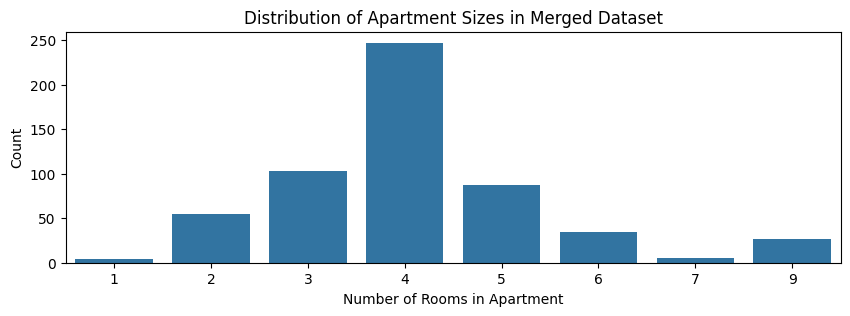

In [30]:
# Distribution of apartment sizes
plt.figure(figsize=(10,3))
sns.countplot(data=merged_df, x="ApartmentSize", order=sorted(merged_df["ApartmentSize"].dropna().unique()))
plt.title("Distribution of Apartment Sizes in Merged Dataset")
plt.xlabel("Number of Rooms in Apartment")
plt.ylabel("Count")
plt.show()

In [31]:
# Average length of stay in days in the merged dataset

avg_length_of_stay = merged_df["LengthOfStay_days"].mean()
print("Average length of stay (days) in merged dataset:", avg_length_of_stay)

Average length of stay (days) in merged dataset: 136.23268206039077


In [32]:
# Average RemainingStay_days in the merged dataset

avg_remaining_stay = merged_df["RemainingStay_days"].mean()
print("Average remaining stay (days) in merged dataset:", avg_remaining_stay)

Average remaining stay (days) in merged dataset: 188.2575488454707


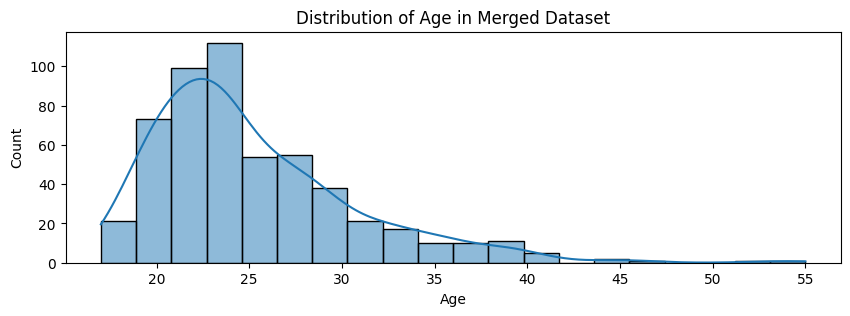

In [33]:
# Distribution of Age in the merged dataset
plt.figure(figsize=(10,3))
sns.histplot(merged_df["Age"].dropna(), bins=20, kde=True)
plt.title("Distribution of Age in Merged Dataset")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

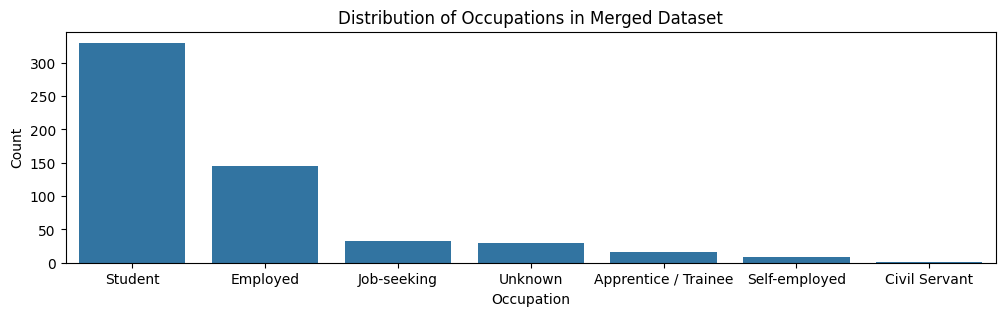

In [34]:
# Distribution of occupations in the merged dataset as a vertical bar plot

plt.figure(figsize=(12,3))
sns.countplot(data=merged_df, x="Occupation", order=merged_df["Occupation"].value_counts().index)
plt.title("Distribution of Occupations in Merged Dataset")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.show()

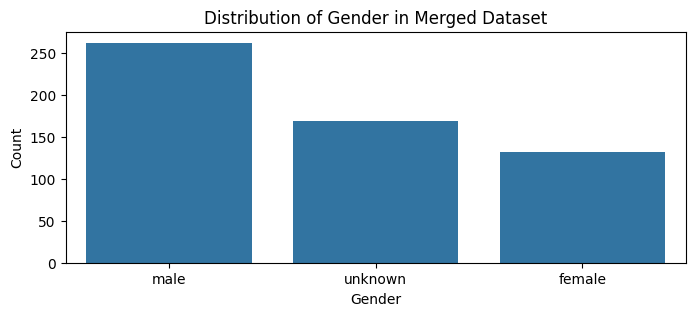

In [35]:
# Distribution of gender in the merged dataset

plt.figure(figsize=(8,3))
sns.countplot(data=merged_df, x="Gender")       
plt.title("Distribution of Gender in Merged Dataset")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()  

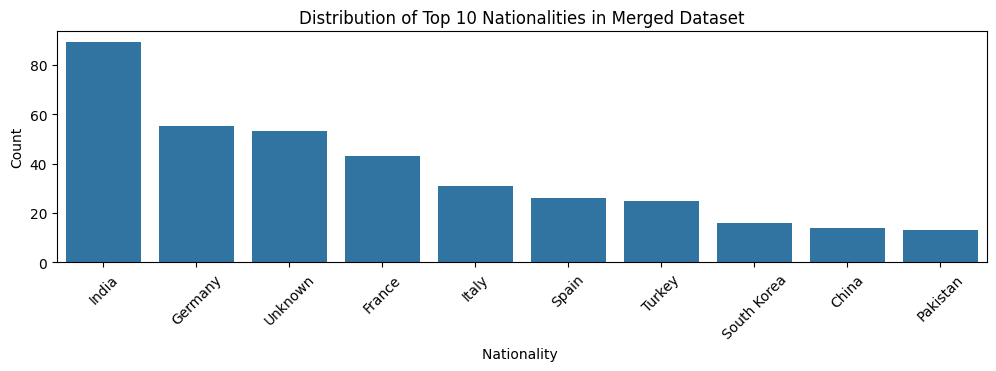

In [36]:
# Distribution of nationalities limited to top 10 most common
top_nationalities = merged_df["Nationality"].value_counts().nlargest(10).index
plt.figure(figsize=(12,3))
sns.countplot(data=merged_df, x="Nationality", order=top_nationalities)
plt.title("Distribution of Top 10 Nationalities in Merged Dataset")
plt.xlabel("Nationality ")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [37]:
# Distribution of personality traits

merged_df[["Extraversion", "Agreeableness",
           "Conscientiousness", "Emotional_Stability", "Openness"]].describe()

,Extraversion,Agreeableness,Conscientiousness,Emotional_Stability,Openness
count,563.00000,563.000000,563.000000,563.000000,563.000000
mean,2.98579,3.031083,3.006217,2.953819,2.988455
std,0.59787,0.590111,0.607966,0.616065,0.631576
min,1.00000,1.500000,1.500000,1.000000,1.500000
25%,2.50000,2.500000,2.500000,2.500000,2.500000
50%,3.00000,3.000000,3.000000,3.000000,3.000000
75%,3.50000,3.500000,3.500000,3.500000,3.500000
max,4.50000,4.500000,5.000000,5.000000,5.000000


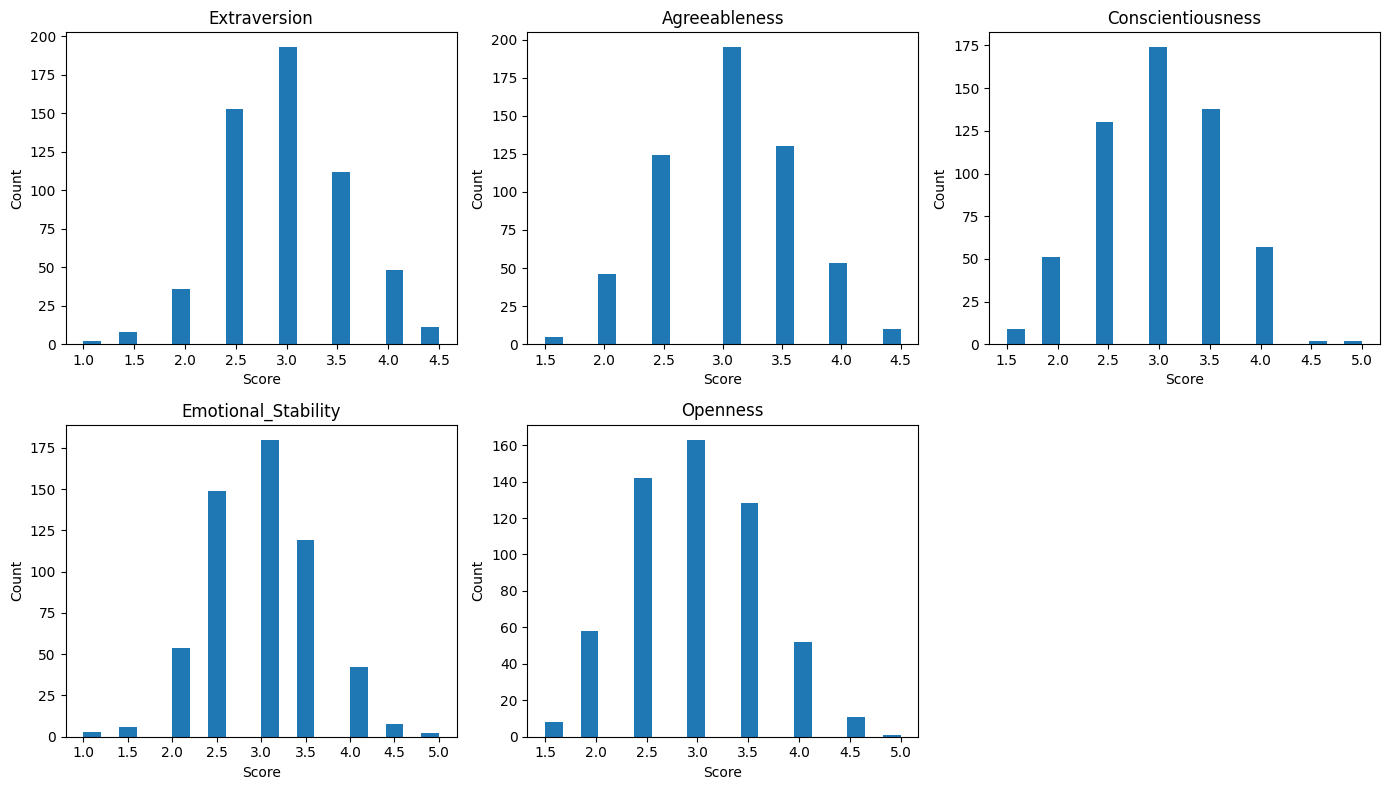

In [38]:
# Visualize the distribution of personality traits

traits = [
    "Extraversion",
    "Agreeableness",
    "Conscientiousness",
    "Emotional_Stability",
    "Openness"
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, trait in zip(axes, traits):
    ax.hist(merged_df[trait], bins=20)
    ax.set_title(trait)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")

axes[-1].axis("off")  # remove empty subplot
plt.tight_layout()
plt.show()

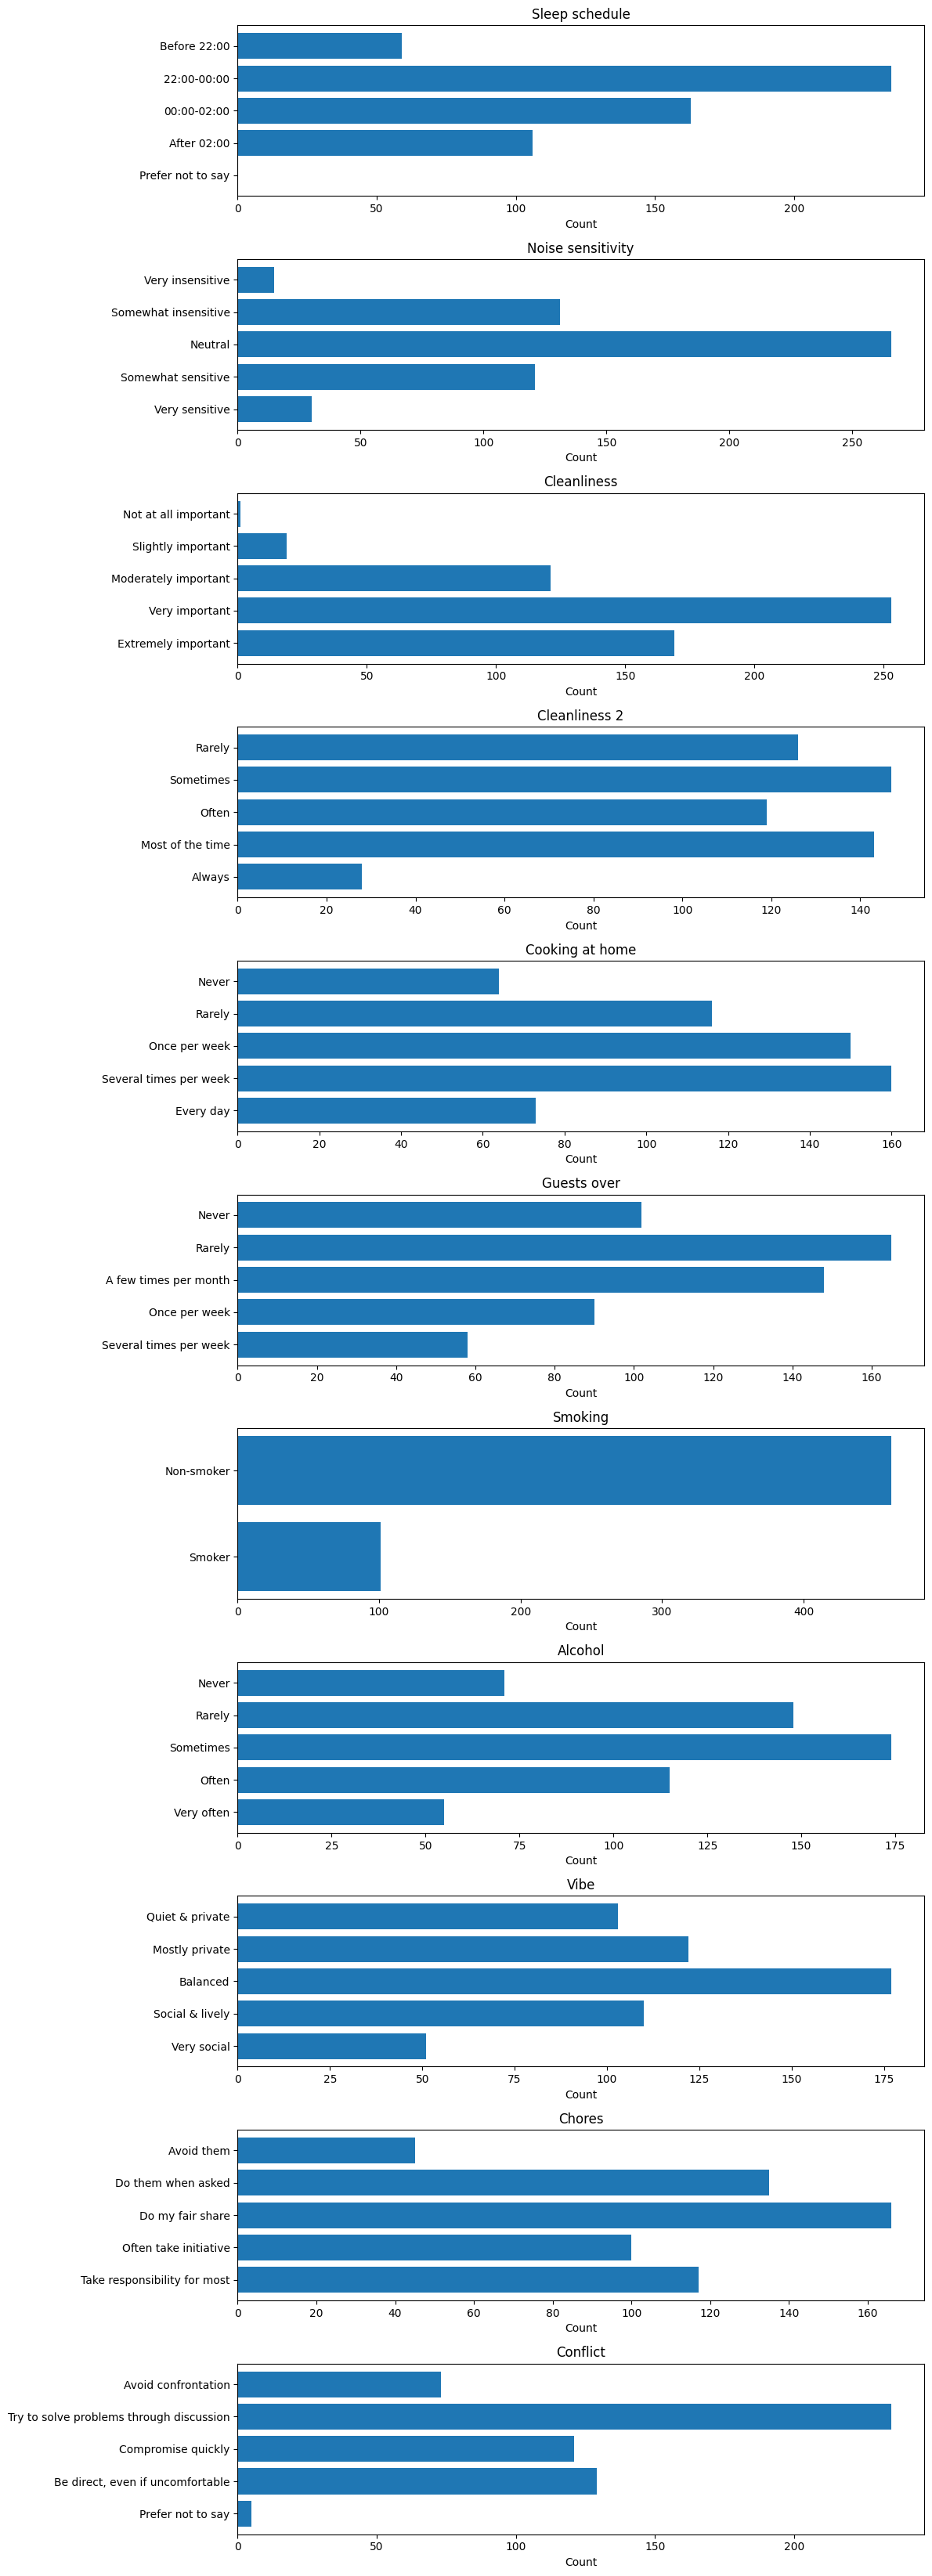

In [39]:
# Visualize the distribution of key ordinal survey variables with original labels

vars_to_plot = [
    "Sleep_schedule", "Noise_sensitivity", "Cleanliness", "Cleanliness_2",
    "Cooking_at_home", "Guests_over", "Smoking", "Alcohol",
    "Vibe", "Chores", "Conflict"
]

plot_orders = {
    # FIXED: use hyphen '-' to match your data (not en-dash '–')
    "Sleep_schedule": [
        "Before 22:00", "22:00-00:00", "00:00-02:00", "After 02:00", "Prefer not to say"
    ],
    "Noise_sensitivity": [
        "Very insensitive", "Somewhat insensitive", "Neutral",
        "Somewhat sensitive", "Very sensitive"
    ],
    "Cleanliness": [
        "Not at all important", "Slightly important", "Moderately important",
        "Very important", "Extremely important"
    ],
    "Cleanliness_2": [
        "Rarely", "Sometimes", "Often", "Most of the time", "Always"
    ],
    "Cooking_at_home": [
        "Never", "Rarely", "Once per week", "Several times per week", "Every day"
    ],
    "Guests_over": [
        "Never", "Rarely", "A few times per month", "Once per week", "Several times per week"
    ],
    "Smoking": ["Non-smoker", "Smoker"],
    "Alcohol": ["Never", "Rarely", "Sometimes", "Often", "Very often"],
    "Vibe": [
        "Quiet & private", "Mostly private", "Balanced",
        "Social & lively", "Very social"
    ],
    "Chores": [
        "Avoid them", "Do them when asked", "Do my fair share",
        "Often take initiative", "Take responsibility for most"
    ],
    "Conflict": [
        "Avoid confrontation",
        "Try to solve problems through discussion",
        "Compromise quickly",
        "Be direct, even if uncomfortable",
        "Prefer not to say"
    ],
}

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(12, 3 * len(vars_to_plot)))

for ax, var in zip(axes, vars_to_plot):
    order = plot_orders[var]

    counts = merged_df[var].value_counts()
    extras = [x for x in counts.index.tolist() if x not in order]
    full_order = order + extras

    counts = counts.reindex(full_order, fill_value=0)

    # horizontal bars for ALL variables
    ax.barh(full_order, counts.values)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    ax.invert_yaxis()  # keeps your intended order top->bottom
    ax.set_title(var.replace("_", " "))

plt.tight_layout()
plt.show()


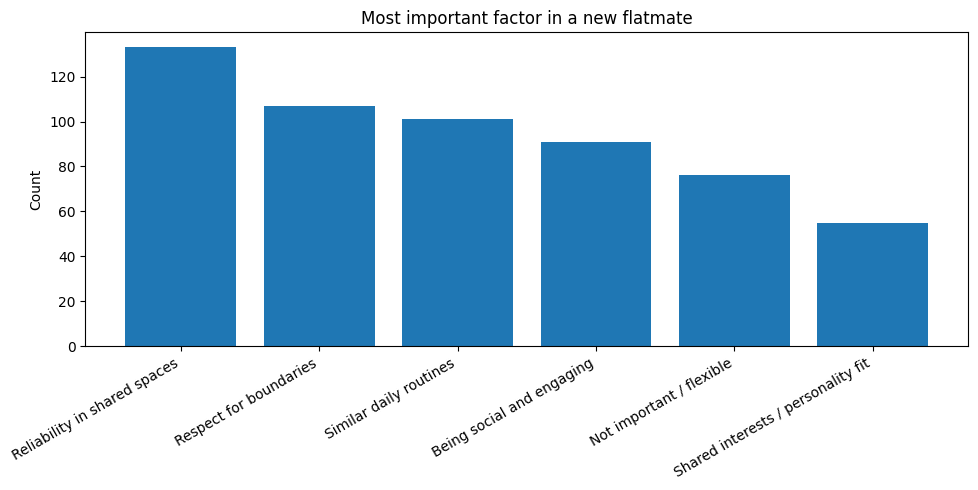

In [40]:
# Visualize the distribution of the most important factor in a new flatmate

counts = merged_df["FlatmateFactors_Priority"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.title("Most important factor in a new flatmate")
plt.tight_layout()
plt.show()

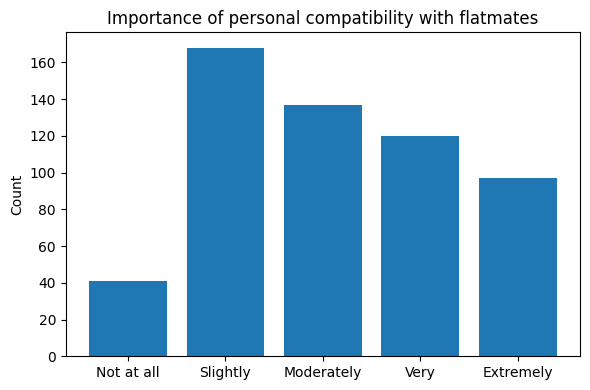

In [41]:
# Importance of personal compatibility with flatmates

order = ["Not at all", "Slightly", "Moderately", "Very", "Extremely"]

counts = merged_df["Compatibility_Importance"].value_counts()
counts = counts.reindex(order, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.ylabel("Count")
plt.title("Importance of personal compatibility with flatmates")
plt.tight_layout()
plt.show()

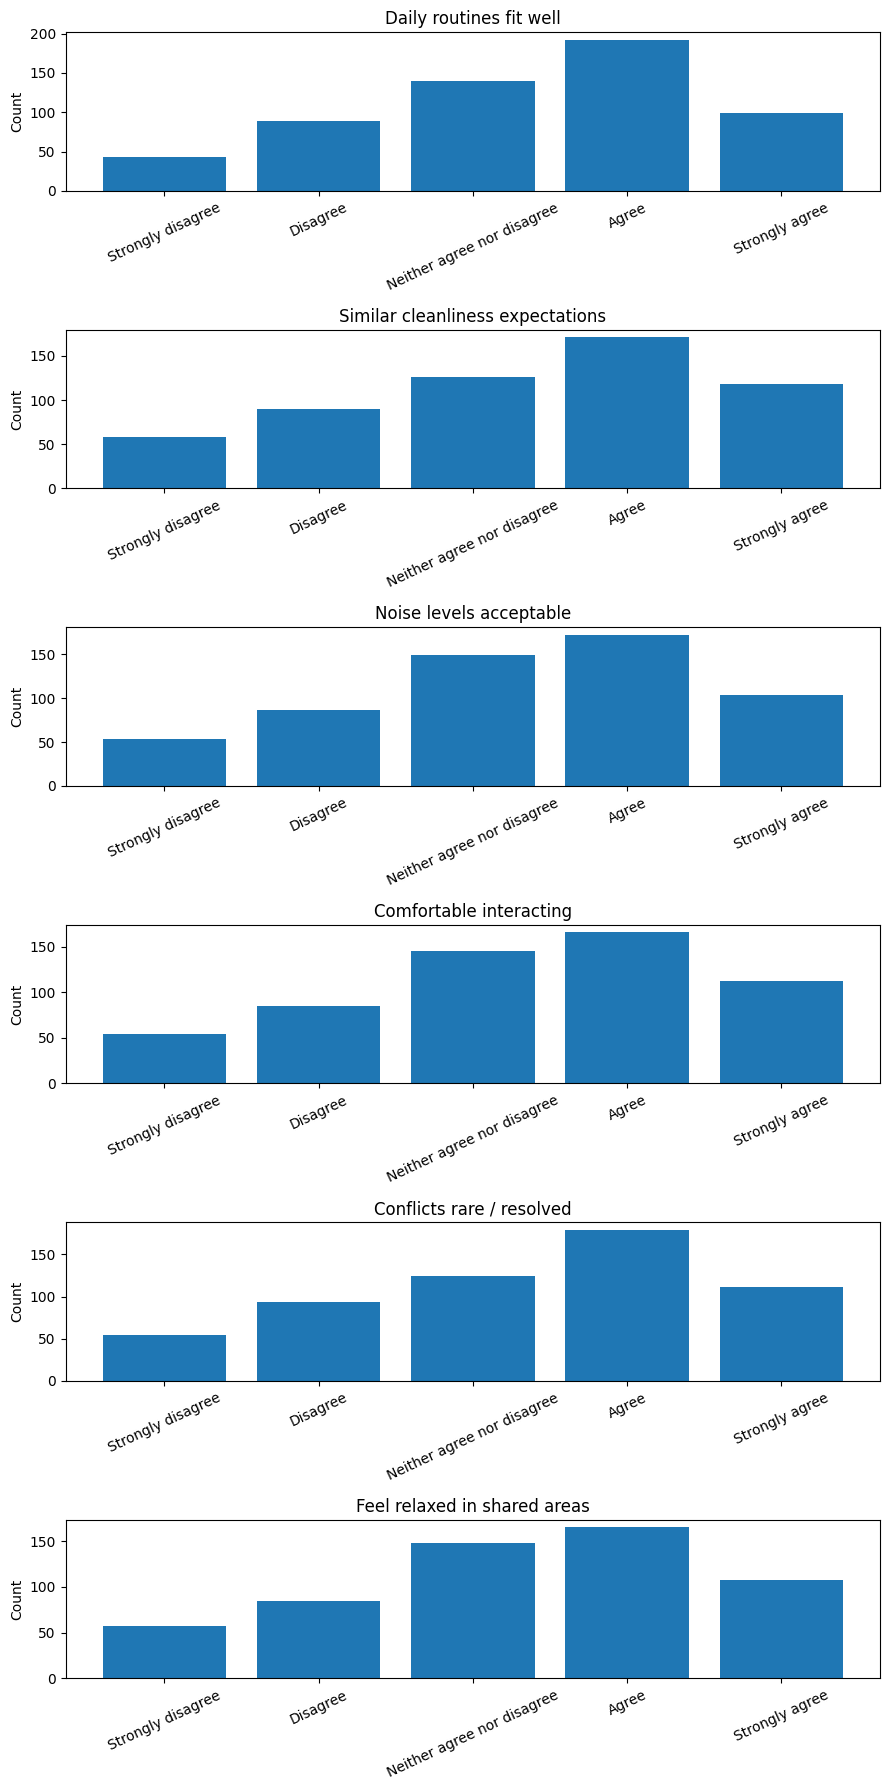

In [42]:
# Compatiblity ratings for different facets of flatmate compatibility

likert_order = ["Strongly disagree", "Disagree", "Neither agree nor disagree", "Agree", "Strongly agree"]

facet_cols = {
    "Compat_DailyRoutines": "Daily routines fit well",
    "Compat_Tidiness": "Similar cleanliness expectations",
    "Compat_Noise": "Noise levels acceptable",
    "Compat_Interaction": "Comfortable interacting",
    "Compat_Conflict": "Conflicts rare / resolved",
    "Compat_Relaxedness": "Feel relaxed in shared areas"
}

fig, axes = plt.subplots(len(facet_cols), 1, figsize=(9, 3 * len(facet_cols)))

for ax, (col, title) in zip(axes, facet_cols.items()):
    counts = merged_df[col].value_counts().reindex(likert_order)

    ax.bar(counts.index, counts.values)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


In [43]:
# Compatibility columns summary statistics

compat_cols = [
    "Compatibility_OverallRating",
    "Compat_DailyRoutines",
    "Compat_Tidiness",
    "Compat_Noise",
    "Compat_Interaction",
    "Compat_Conflict",
    "Compat_Relaxedness"
]

merged_df[compat_cols].describe()

,Compatibility_OverallRating,Compat_DailyRoutines,Compat_Tidiness,Compat_Noise,Compat_Interaction,Compat_Conflict,Compat_Relaxedness
count,563,563,563,563,563,563,563
unique,5,5,5,5,5,5,5
top,Slightly compatible,Agree,Agree,Agree,Agree,Agree,Agree
freq,166,192,171,172,166,179,165


In [44]:
# Overall compatilbity within apartments and their deviation from the apartment mean

# 1) Map the ordered categories to numbers

rating_map = {
    "Not at all compatible": 1,
    "Slightly compatible": 2,
    "Moderately compatible": 3,
    "Very compatible": 4,
    "Extremely compatible": 5
}

merged_df["Compatibility_OverallRating_num"] = (
    merged_df["Compatibility_OverallRating"]
    .map(rating_map)
    .astype("float")
)

# 2) Groupby using the numeric version
apt_agreement = (
    merged_df
    .groupby("Apartment")["Compatibility_OverallRating_num"]
    .agg(mean="mean", within_apartment_std="std", count="count")
)

apt_agreement.head(50)

,mean,within_apartment_std,count
Apartment,,,
A.01,4.000000,0.000000,2
A.02,2.500000,2.121320,2
A.03,2.750000,0.957427,4
A.04,2.666667,1.527525,3
A.05,3.000000,0.000000,4
A.06,1.750000,0.957427,4
A.11,2.500000,2.121320,2
A.12,2.666667,2.081666,3
A.13,3.750000,1.500000,4


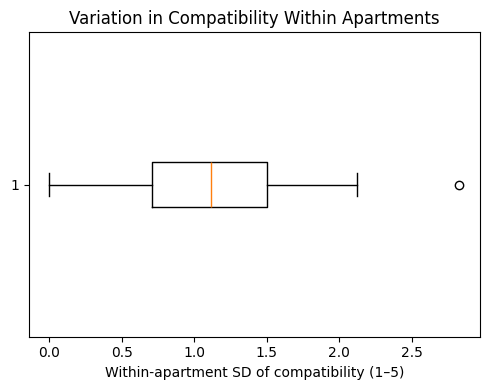

In [45]:
# Boxplot of within-apartment standard deviations of compatibility ratings

compat_num = merged_df["Compatibility_OverallRating"].map(rating_map)

within_sd = (
    pd.DataFrame({"Apartment": merged_df["Apartment"], "compat_num": compat_num})
    .groupby("Apartment")["compat_num"]
    .std()
    .dropna()
)

plt.figure(figsize=(5, 4))
plt.boxplot(within_sd, vert=False)
plt.xlabel("Within-apartment SD of compatibility (1–5)")
plt.title("Variation in Compatibility Within Apartments")
plt.tight_layout()
plt.show()


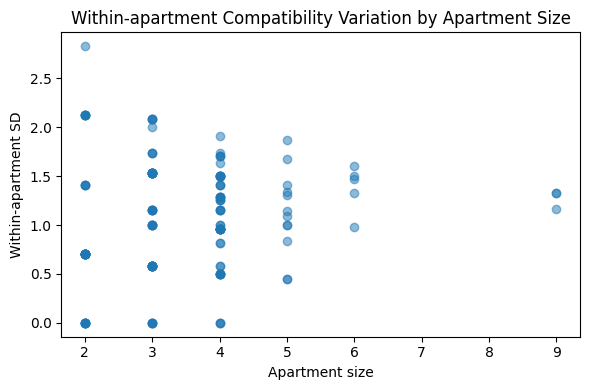

In [46]:
# Scatter plot of within-apartment SD vs apartment size

apt_stats = (
    merged_df
    .assign(compat_num=compat_num)
    .groupby("Apartment")
    .agg(
        sd=("compat_num", "std"),
        size=("compat_num", "count")
    )
    .dropna()
)

plt.figure(figsize=(6, 4))
plt.scatter(apt_stats["size"], apt_stats["sd"], alpha=0.5)
plt.xlabel("Apartment size")
plt.ylabel("Within-apartment SD")
plt.title("Within-apartment Compatibility Variation by Apartment Size")
plt.tight_layout()
plt.show()


## Compatilbity Modelling

### Part 1 - Unsupervised Learning: PCA and clustering latent tenant



In [47]:
# Drop IPIP columns now that we have the aggregated traits and check final dtypes
ipip_cols = [f"IPIP_{i}" for i in range(1, 11)]
merged_df = merged_df.drop(columns=ipip_cols)   
print(merged_df.dtypes)

Apartment                           object
Sleep_schedule                      object
Noise_sensitivity                   object
Cleanliness                         object
Cleanliness_2                       object
Cooking_at_home                     object
Guests_over                         object
Smoking                             object
Alcohol                             object
Vibe                                object
Chores                              object
Conflict                            object
FlatmateFactors_Priority            object
Compatibility_Importance            object
Compatibility_OverallRating         object
Compat_DailyRoutines                object
Compat_Tidiness                     object
Compat_Noise                        object
Compat_Interaction                  object
Compat_Conflict                     object
Compat_Relaxedness                  object
Unit                                object
Gender                              object
Age        

In [48]:
# Final list of features to use in the model (after encoding and aggregation)

model_features = [
    # Big Five (already numeric)
    "Emotional_Stability", "Extraversion", "Openness",
    "Conscientiousness", "Agreeableness",

    # Lifestyle / preferences (your encoded ordinals)
    "Noise_sensitivity_num", "Cleanliness_num", "Cleanliness_2_num",
    "Cooking_at_home_num", "Guests_over_num", "Alcohol_num",
    "Vibe_num", "Chores_num",
    "Compatibility_Importance_num",

    # Binary
    "Smoking_num",

    # Demographics numeric
    "Age", "LengthOfStay_days", "RemainingStay_days", "ApartmentSize",
]


In [49]:
# Predictors and IDs

id_cols = ["Apartment", "Unit"]

X = merged_df[model_features].copy()
ids = merged_df[id_cols].copy()

In [50]:
# Sanity check on missing values in predictors

print("X shape:", X.shape)
print("Missing rate (top):")
print(X.isna().mean().sort_values(ascending=False).head(10))

X shape: (563, 19)
Missing rate (top):
Age                             0.056838
Emotional_Stability             0.000000
Alcohol_num                     0.000000
RemainingStay_days              0.000000
LengthOfStay_days               0.000000
Smoking_num                     0.000000
Compatibility_Importance_num    0.000000
Chores_num                      0.000000
Vibe_num                        0.000000
Guests_over_num                 0.000000
dtype: float64


In [51]:
# Impute missing values in predictors using median imputation
X["Age"] = X["Age"].fillna(X["Age"].median())

In [52]:
# One-hot encode Conflict (drop reference category)

conflict_dummies = pd.get_dummies(
    merged_df["Conflict"],
    prefix="Conflict",
    drop_first=True
)

# Inspect columns (sanity check)
print(conflict_dummies.columns)

Index(['Conflict_Be direct, even if uncomfortable',
       'Conflict_Compromise quickly', 'Conflict_Prefer not to say',
       'Conflict_Try to solve problems through discussion'],
      dtype='object')


In [53]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# Sanity checks
print(X_scaled.mean().abs().sort_values(ascending=False).head())
print(X_scaled.std().round(2).head())

Age                  3.249818e-16
Extraversion         2.965853e-16
Cleanliness_num      1.956201e-16
ApartmentSize        1.766891e-16
Conscientiousness    1.640685e-16
dtype: float64
Emotional_Stability    1.0
Extraversion           1.0
Openness               1.0
Conscientiousness      1.0
Agreeableness          1.0
dtype: float64


In [54]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var = np.cumsum(pca.explained_variance_ratio_)

for i, v in enumerate(explained_var[:10], start=1):
    print(f"PC{i}: cumulative explained variance = {v:.3f}")

PC1: cumulative explained variance = 0.093
PC2: cumulative explained variance = 0.164
PC3: cumulative explained variance = 0.231
PC4: cumulative explained variance = 0.295
PC5: cumulative explained variance = 0.357
PC6: cumulative explained variance = 0.416
PC7: cumulative explained variance = 0.475
PC8: cumulative explained variance = 0.532
PC9: cumulative explained variance = 0.586
PC10: cumulative explained variance = 0.637


In [55]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(len(X.columns))]
)

# Show top contributors for first few components
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop loadings for {pc}")
    print(loadings[pc].sort_values(key=np.abs, ascending=False).head(8))


Top loadings for PC1
LengthOfStay_days               0.644254
RemainingStay_days             -0.627912
Age                             0.298729
Vibe_num                       -0.145277
Compatibility_Importance_num    0.137266
Extraversion                   -0.109101
Conscientiousness               0.104780
Alcohol_num                     0.093584
Name: PC1, dtype: float64

Top loadings for PC2
Agreeableness          0.450660
Cleanliness_2_num      0.400309
Cooking_at_home_num    0.395288
Chores_num             0.292504
Age                   -0.274151
ApartmentSize          0.266746
Cleanliness_num       -0.255509
Smoking_num            0.207748
Name: PC2, dtype: float64

Top loadings for PC3
Alcohol_num          0.468114
Smoking_num          0.437821
Conscientiousness    0.376376
Agreeableness        0.296086
ApartmentSize       -0.274143
Openness            -0.212163
Age                  0.206161
Cleanliness_num      0.202357
Name: PC3, dtype: float64


In [56]:
n_components = 6  # example – we’ll set this based on what you see

pca = PCA(n_components=n_components)
X_pca_reduced = pca.fit_transform(X_scaled)

print("Reduced PCA shape:", X_pca_reduced.shape)


Reduced PCA shape: (563, 6)


In [57]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_reduced)
    inertias.append(km.inertia_)

for k, inertia in zip(K_range, inertias):
    print(f"k={k}, inertia={inertia:.2f}")

k=2, inertia=3744.60
k=3, inertia=3399.71
k=4, inertia=3105.08
k=5, inertia=2904.95
k=6, inertia=2727.40
k=7, inertia=2582.70
k=8, inertia=2453.33
k=9, inertia=2366.21
k=10, inertia=2295.46


In [58]:
k = 4  # example, adjust based on elbow

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca_reduced)

merged_df["Cluster_Task2"] = clusters


In [59]:
cluster_profiles = (
    merged_df
    .groupby("Cluster_Task2")[X.columns]
    .mean()
)

print(cluster_profiles)

               Emotional_Stability  Extraversion  Openness  Conscientiousness  \
Cluster_Task2                                                                   
0                         2.904762      2.899471  3.068783           3.055556   
1                         2.697368      3.236842  3.083333           2.877193   
2                         3.184028      2.857639  2.975694           2.750000   
3                         3.000000      3.038793  2.780172           3.370690   

               Agreeableness  Noise_sensitivity_num  Cleanliness_num  \
Cluster_Task2                                                          
0                   3.007937               3.000000         4.000000   
1                   3.118421               3.491228         3.894737   
2                   2.729167               2.930556         3.979167   
3                   3.357759               2.775862         4.189655   

               Cleanliness_2_num  Cooking_at_home_num  Guests_over_num  \
Cluste

### Part 2 - Supervised Learning: Predicting compatiblity 

In [60]:
# Apartment identifier
apt_id = "Apartment"

# Create base apartment dataframe
apt_df = (
    merged_df
    .groupby(apt_id)
    .size()
    .to_frame(name="n_tenants")
)

print(apt_df.head())
print("Number of apartments:", apt_df.shape[0])


           n_tenants
Apartment           
A.01               2
A.02               2
A.03               4
A.04               3
A.05               4
Number of apartments: 167


In [61]:
# Number of PCA components you kept
n_components = X_pca_reduced.shape[1]

# Create column names
pca_cols = [f"PC{i+1}" for i in range(n_components)]

# Attach PCA scores to merged_df
merged_df[pca_cols] = X_pca_reduced


In [62]:
# Mean PCA profile per apartment
apt_pca_mean = (
    merged_df
    .groupby("Apartment")[pca_cols]
    .mean()
    .add_suffix("_mean")
)

# Merge into apartment dataframe
apt_df = apt_df.join(apt_pca_mean)

print(apt_df.head())



           n_tenants  PC1_mean  PC2_mean  PC3_mean  PC4_mean  PC5_mean  \
Apartment                                                                
A.01               2 -1.134907 -0.117357  0.504604  0.062601 -0.308713   
A.02               2 -1.734613 -1.072778 -0.264766 -0.692802  0.175403   
A.03               4 -1.373628  0.015805 -0.210666  0.098068  0.488300   
A.04               3 -0.610357 -0.291199  0.396029  0.491578  1.066169   
A.05               4 -0.917931 -1.427818 -0.309909 -0.822067  0.288168   

           PC6_mean  
Apartment            
A.01       0.306600  
A.02       1.138683  
A.03       0.761960  
A.04       1.028952  
A.05      -0.579896  


In [63]:
# Within-apartment dispersion (standard deviation of PCA scores)
apt_pca_std = (
    merged_df
    .groupby("Apartment")[pca_cols]
    .std()
    .add_suffix("_std")
)

# Merge into apartment dataframe
apt_df = apt_df.join(apt_pca_std)

print(apt_df.head())


           n_tenants  PC1_mean  PC2_mean  PC3_mean  PC4_mean  PC5_mean  \
Apartment                                                                
A.01               2 -1.134907 -0.117357  0.504604  0.062601 -0.308713   
A.02               2 -1.734613 -1.072778 -0.264766 -0.692802  0.175403   
A.03               4 -1.373628  0.015805 -0.210666  0.098068  0.488300   
A.04               3 -0.610357 -0.291199  0.396029  0.491578  1.066169   
A.05               4 -0.917931 -1.427818 -0.309909 -0.822067  0.288168   

           PC6_mean   PC1_std   PC2_std   PC3_std   PC4_std   PC5_std  \
Apartment                                                               
A.01       0.306600  0.215399  1.038948  0.685701  1.565665  0.072222   
A.02       1.138683  0.117412  0.215818  1.203076  0.559251  1.300238   
A.03       0.761960  0.142853  0.531685  1.099141  0.884211  1.010966   
A.04       1.028952  1.143608  0.511439  0.914057  1.139218  1.899565   
A.05      -0.579896  1.179730  1.073980  0.

In [64]:
apt_df.filter(like="_std").describe()

,PC1_std,PC2_std,PC3_std,PC4_std,PC5_std,PC6_std
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,1.132597,0.962862,0.960102,0.988942,0.931932,0.819047
std,0.618609,0.442653,0.531857,0.492925,0.475166,0.452405
min,0.007029,0.035119,0.045862,0.000022,0.072222,0.001332
25%,0.681603,0.732696,0.594927,0.611386,0.587752,0.470432
50%,1.072483,0.952946,0.855559,0.959258,0.854733,0.757482
75%,1.478235,1.150969,1.289640,1.290912,1.207714,1.189555
max,3.960227,2.291028,2.969922,2.764396,2.543436,2.261834


In [66]:
# 1) Add apartment size (one value per apartment)
apt_size = (
    merged_df.groupby("Apartment")["ApartmentSize"]
    .first()
    .rename("ApartmentSize")
)

# Join with suffix handling (only matters if ApartmentSize already exists)
apt_df = apt_df.join(apt_size, rsuffix="_from_data")

# If you ended up with ApartmentSize_from_data, prefer that and drop the old one
if "ApartmentSize_from_data" in apt_df.columns:
    apt_df["ApartmentSize"] = apt_df["ApartmentSize_from_data"]
    apt_df = apt_df.drop(columns=["ApartmentSize_from_data"])

# 2) Occupancy features
apt_df["free_rooms"] = apt_df["ApartmentSize"] - apt_df["n_tenants"]
apt_df["occupancy_rate"] = apt_df["n_tenants"] / apt_df["ApartmentSize"]

# Quick check
apt_df[["n_tenants", "ApartmentSize", "free_rooms", "occupancy_rate"]].head()


,n_tenants,ApartmentSize,free_rooms,occupancy_rate
Apartment,,,,
A.01,2,2,0,1.0
A.02,2,2,0,1.0
A.03,4,4,0,1.0
A.04,3,3,0,1.0
A.05,4,4,0,1.0


In [68]:
# Cross-tab: how many tenants of each cluster per apartment
cluster_counts = pd.crosstab(
    merged_df["Apartment"],
    merged_df["Cluster_Task2"]
)

# Convert to proportions (row-wise normalization)
cluster_shares = cluster_counts.div(cluster_counts.sum(axis=1), axis=0)

# Rename columns for clarity
cluster_shares = cluster_shares.add_prefix("cluster_share_")

# Merge into apartment-level dataframe
apt_df = apt_df.join(cluster_shares)

apt_df.head()



,n_tenants,PC1_mean,PC2_mean,PC3_mean,PC4_mean,PC5_mean,PC6_mean,PC1_std,PC2_std,PC3_std,PC4_std,PC5_std,PC6_std,ApartmentSize,free_rooms,occupancy_rate,cluster_share_0,cluster_share_1,cluster_share_2,cluster_share_3
Apartment,,,,,,,,,,,,,,,,,,,,
A.01,2,-1.134907,-0.117357,0.504604,0.062601,-0.308713,0.306600,0.215399,1.038948,0.685701,1.565665,0.072222,1.296306,2,0,1.0,0.0,0.50,0.500000,0.000000
A.02,2,-1.734613,-1.072778,-0.264766,-0.692802,0.175403,1.138683,0.117412,0.215818,1.203076,0.559251,1.300238,0.689650,2,0,1.0,0.0,0.50,0.500000,0.000000
A.03,4,-1.373628,0.015805,-0.210666,0.098068,0.488300,0.761960,0.142853,0.531685,1.099141,0.884211,1.010966,0.838463,4,0,1.0,0.0,0.50,0.250000,0.250000
A.04,3,-0.610357,-0.291199,0.396029,0.491578,1.066169,1.028952,1.143608,0.511439,0.914057,1.139218,1.899565,0.659176,3,0,1.0,0.0,0.00,0.333333,0.666667
A.05,4,-0.917931,-1.427818,-0.309909,-0.822067,0.288168,-0.579896,1.179730,1.073980,0.857381,0.550575,0.617393,0.492375,4,0,1.0,0.0,0.25,0.500000,0.250000


In [71]:
# Extract apartment PCA mean columns
apt_pca_means = apt_df.filter(like="_mean")

apt_pca_means.head()



,PC1_mean,PC2_mean,PC3_mean,PC4_mean,PC5_mean,PC6_mean
Apartment,,,,,,
A.01,-1.134907,-0.117357,0.504604,0.062601,-0.308713,0.306600
A.02,-1.734613,-1.072778,-0.264766,-0.692802,0.175403,1.138683
A.03,-1.373628,0.015805,-0.210666,0.098068,0.488300,0.761960
A.04,-0.610357,-0.291199,0.396029,0.491578,1.066169,1.028952
A.05,-0.917931,-1.427818,-0.309909,-0.822067,0.288168,-0.579896


In [72]:
# Function to compute Euclidean distance
def compute_fit(row):
    apt = row["Apartment"]
    tenant_vec = row[pca_cols].values
    apt_vec = apt_pca_means.loc[apt].values
    return np.linalg.norm(tenant_vec - apt_vec)

merged_df["fit_distance"] = merged_df.apply(compute_fit, axis=1)

merged_df[["Apartment", "fit_distance"]].head()

,Apartment,fit_distance
0,A.01,1.693064
1,A.01,1.693064
2,A.02,1.411870
3,A.02,1.411870
4,A.03,1.099661


In [73]:
merged_df["fit_distance"].describe()


count    563.000000
mean       2.125195
std        0.708438
min        0.000000
25%        1.684185
50%        2.123520
75%        2.584286
max        4.382674
Name: fit_distance, dtype: float64

In [75]:
merged_df[["fit_distance", "Compatibility_OverallRating_num"]].corr()

,fit_distance,Compatibility_OverallRating_num
fit_distance,1.000000,0.002769
Compatibility_OverallRating_num,0.002769,1.000000


In [76]:
apt_compat = merged_df.groupby("Apartment")[
    "Compatibility_OverallRating_num"
].mean()

apt_df = apt_df.join(apt_compat.rename("compat_mean"))


In [90]:
apt_df[["compat_mean"] + list(apt_df.filter(like="_std").columns)].corr()


,compat_mean,PC1_std,PC2_std,PC3_std,PC4_std,PC5_std,PC6_std
compat_mean,1.000000,-0.055173,-0.139118,-0.072163,0.131152,0.038709,0.047732
PC1_std,-0.055173,1.000000,0.180413,-0.058866,-0.050054,0.077198,-0.030939
PC2_std,-0.139118,0.180413,1.000000,0.231684,-0.064125,0.242168,0.025318
PC3_std,-0.072163,-0.058866,0.231684,1.000000,-0.072389,0.198103,0.024370
PC4_std,0.131152,-0.050054,-0.064125,-0.072389,1.000000,0.108440,-0.066065
PC5_std,0.038709,0.077198,0.242168,0.198103,0.108440,1.000000,-0.052575
PC6_std,0.047732,-0.030939,0.025318,0.024370,-0.066065,-0.052575,1.000000


In [91]:
# Average PCA dispersion across components
std_cols = [c for c in apt_df.columns if c.endswith("_std")]

apt_df["mean_dispersion"] = apt_df[std_cols].mean(axis=1)


In [92]:
cluster_cols = [c for c in apt_df.columns if c.startswith("cluster_share_")]

apt_df["cluster_dominance"] = apt_df[cluster_cols].max(axis=1)


In [93]:
apt_df["occupancy_rate"]


Apartment
A.01     1.0
A.02     1.0
A.03     1.0
A.04     1.0
A.05     1.0
        ... 
TU.51    1.0
TU.52    0.5
TU.53    0.8
TU.54    1.0
TU.55    1.0
Name: occupancy_rate, Length: 167, dtype: Float64

In [94]:
score_features = [
    "mean_dispersion",
    "cluster_dominance",
    "occupancy_rate"
]

scaler_score = StandardScaler()

scaled = scaler_score.fit_transform(apt_df[score_features])

apt_df[["disp_z", "dominance_z", "occupancy_z"]] = scaled

In [95]:
apt_df["designed_compat_score"] = (
    -apt_df["disp_z"] +
     apt_df["dominance_z"] -
     apt_df["occupancy_z"]
)


In [96]:
apt_df[["designed_compat_score", "compat_mean"]].corr()


,designed_compat_score,compat_mean
designed_compat_score,1.000000,-0.027876
compat_mean,-0.027876,1.000000


In [98]:
# --- AFTER apt_df is created and contains PC*_mean ---

import re

# Align PCs between tenant and apartment representations
pca_mean_cols = [c for c in apt_df.columns if re.match(r"^PC\d+_mean$", c)]
pca_mean_cols = sorted(pca_mean_cols, key=lambda x: int(re.findall(r"\d+", x)[0]))

pc_names_from_means = [c.replace("_mean", "") for c in pca_mean_cols]
pc_names = [pc for pc in pc_names_from_means if pc in merged_df.columns]
pca_mean_cols = [pc + "_mean" for pc in pc_names]

print("Using PCs:", pc_names)


Using PCs: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']


In [101]:
# ---------------------------------------------------------
# 0) ALIGN PCA COLUMNS between merged_df (tenant PCs) and apt_df (PC*_mean)
#    Place this AFTER you have already created merged_df[PC*] and apt_df[PC*_mean]
# ---------------------------------------------------------
pca_mean_cols = [c for c in apt_df.columns if re.match(r"^PC\d+_mean$", c)]
pca_mean_cols = sorted(pca_mean_cols, key=lambda x: int(re.findall(r"\d+", x)[0]))

pc_names_from_means = [c.replace("_mean", "") for c in pca_mean_cols]
pc_names = [pc for pc in pc_names_from_means if pc in merged_df.columns]  # keep only PCs present in merged_df
pca_mean_cols = [pc + "_mean" for pc in pc_names]

print("Using PCs:", pc_names)
print("Apartment mean cols:", pca_mean_cols)

# ---------------------------------------------------------
# 1) Helper: z-score a Series
# ---------------------------------------------------------
def zscore(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

# ---------------------------------------------------------
# 2) Prep apartment-side fields needed for scoring
# ---------------------------------------------------------
# PCA std cols (for dispersion)
pca_std_cols = [c for c in apt_df.columns if re.match(r"^PC\d+_std$", c)]
pca_std_cols = sorted(pca_std_cols, key=lambda x: int(re.findall(r"\d+", x)[0]))
pca_std_cols = [c for c in pca_std_cols if c.replace("_std", "") in pc_names]  # align to same PCs

# Cluster share cols (for dominance / matching)
cluster_share_cols = [c for c in apt_df.columns if c.startswith("cluster_share_")]

# Dominant cluster per apartment
apt_df["dominant_cluster"] = (
    apt_df[cluster_share_cols]
    .idxmax(axis=1)
    .str.replace("cluster_share_", "", regex=False)
    .astype(int)
)

# Mean dispersion across PCA stds (heterogeneity proxy)
apt_df["mean_dispersion"] = apt_df[pca_std_cols].mean(axis=1)

# ---------------------------------------------------------
# 3) Allocation / ranking function
# ---------------------------------------------------------
def rank_apartments_for_tenant(
    row_idx: int,
    require_vacancy: bool = True,
    exclude_current_apartment: bool = True,
    top_n: int = 15
) -> pd.DataFrame:

    tenant = merged_df.loc[row_idx]
    tenant_vec = tenant[pc_names].values.astype(float)
    tenant_cluster = int(tenant["Cluster_Task2"])
    tenant_apartment = tenant["Apartment"]

    # Candidate apartments
    cand = apt_df.copy()

    if require_vacancy and "free_rooms" in cand.columns:
        cand = cand[cand["free_rooms"] > 0].copy()

    if exclude_current_apartment:
        cand = cand[cand.index != tenant_apartment].copy()

    # Distance to apartment centroid in PCA space
    apt_vecs = cand[pca_mean_cols].values.astype(float)
    dists = np.linalg.norm(apt_vecs - tenant_vec, axis=1)
    cand["fit_distance"] = dists

    # Bonus if tenant cluster matches apartment dominant cluster
    cand["cluster_match"] = (cand["dominant_cluster"] == tenant_cluster).astype(int)

    # Standardize components for scoring (within candidate set)
    cand["dist_z"] = zscore(cand["fit_distance"])
    cand["disp_z"] = zscore(cand["mean_dispersion"])

    # occupancy_rate might be missing if you haven't added it
    if "occupancy_rate" in cand.columns:
        cand["occ_z"] = zscore(cand["occupancy_rate"])
    else:
        cand["occ_z"] = 0.0

    # Weights (tune later)
    w_dist = 1.0
    w_disp = 0.4
    w_occ  = 0.3
    w_match = 0.2

    cand["fit_score"] = (
        -w_dist * cand["dist_z"]      # closer to centroid better
        -w_disp * cand["disp_z"]      # less heterogeneous better
        -w_occ  * cand["occ_z"]       # less crowded better
        +w_match * cand["cluster_match"]
    )

    out = cand.sort_values("fit_score", ascending=False).head(top_n)

    cols_show = [
        "n_tenants", "ApartmentSize", "free_rooms", "occupancy_rate",
        "fit_distance", "mean_dispersion", "dominant_cluster", "cluster_match",
        "fit_score"
    ]
    # Only keep cols that exist
    cols_show = [c for c in cols_show if c in out.columns]

    return out[cols_show]

# ---------------------------------------------------------
# 4) Example usage
# ---------------------------------------------------------
recs = rank_apartments_for_tenant(row_idx=0, require_vacancy=True, exclude_current_apartment=True, top_n=15)
recs.head(10)


Using PCs: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']
Apartment mean cols: ['PC1_mean', 'PC2_mean', 'PC3_mean', 'PC4_mean', 'PC5_mean', 'PC6_mean']


,n_tenants,ApartmentSize,free_rooms,occupancy_rate,fit_distance,mean_dispersion,dominant_cluster,cluster_match,fit_score
Apartment,,,,,,,,,
CU.31,3,5,2,0.6,2.266897,0.551805,0,0,2.02609
D.33,2,4,2,0.5,2.429193,0.549984,1,0,2.012011
B.63,2,3,1,0.666667,1.919691,1.007571,0,0,1.627931
B.14,4,5,1,0.8,1.994236,0.790871,0,0,1.526388
A.56,3,4,1,0.75,2.052780,0.969108,2,1,1.429663
A.35,3,4,1,0.75,2.000718,1.093693,0,0,1.093723
B.61,4,5,1,0.8,2.257063,0.777036,0,0,1.078094
D.53,3,4,1,0.75,2.414816,0.834962,0,0,0.824431
TU.53,4,5,1,0.8,2.341708,0.915661,1,0,0.669806


In [106]:
# Choose axes (start with PC1 & PC2)
x_col = "PC1_mean"
y_col = "PC2_mean"

# Build plotting df (apartments)
plot_df = apt_df.copy().reset_index().rename(columns={"index": "Apartment"})

# Mark top recommendations
top_apts = recs.index.tolist()
plot_df["is_recommended"] = plot_df["Apartment"].isin(top_apts)

# Add fit_score for those apartments (NaN for others)
plot_df["fit_score"] = np.nan
plot_df.loc[plot_df["is_recommended"], "fit_score"] = recs["fit_score"].values

# Tenant point (use tenant PC coords for same components)
tenant_idx = 0  # change if needed
tenant_row = merged_df.loc[tenant_idx]
tenant_x = tenant_row["PC1"]
tenant_y = tenant_row["PC2"]

fig = px.scatter(
    plot_df,
    x=x_col,
    y=y_col,
    hover_data={
        "Apartment": True,
        "n_tenants": True,
        "ApartmentSize": True,
        "free_rooms": True,
        "occupancy_rate": True,
        "mean_dispersion": True,
        "dominant_cluster": True,
        "fit_score": True,
        "is_recommended": True
    },
    symbol="is_recommended",
    size="n_tenants",
)

# Add tenant marker
fig.add_trace(
    go.Scatter(
        x=[tenant_x],
        y=[tenant_y],
        mode="markers",
        marker=dict(size=14, symbol="x"),
        name="Selected tenant",
        hovertext=[f"Tenant idx: {tenant_idx}"],
        hoverinfo="text"
    )
)

fig.update_layout(
    title="Apartment map in PCA space (means) with top recommendations highlighted"
)

fig.show()


In [107]:
def rank_apartments_for_tenant(
    row_idx: int,
    require_vacancy: bool = True,
    exclude_current_apartment: bool = True,
    top_n: int = 15,
    # --- weights ---
    w_dist: float = 1.0,
    w_disp: float = 0.4,
    w_occ: float = 0.3,
    w_match: float = 0.2,
    # --- constraints (optional) ---
    max_occupancy_rate: float | None = None,   # e.g. 0.8
    min_free_rooms: int | None = None          # e.g. 1 or 2
) -> pd.DataFrame:

    tenant = merged_df.loc[row_idx]
    tenant_vec = tenant[pc_names].values.astype(float)
    tenant_cluster = int(tenant["Cluster_Task2"])
    tenant_apartment = tenant["Apartment"]

    cand = apt_df.copy()

    # Vacancy filter
    if require_vacancy and "free_rooms" in cand.columns:
        cand = cand[cand["free_rooms"] > 0].copy()

    # Optional constraints
    if max_occupancy_rate is not None and "occupancy_rate" in cand.columns:
        cand = cand[cand["occupancy_rate"] <= max_occupancy_rate].copy()

    if min_free_rooms is not None and "free_rooms" in cand.columns:
        cand = cand[cand["free_rooms"] >= min_free_rooms].copy()

    if exclude_current_apartment:
        cand = cand[cand.index != tenant_apartment].copy()

    # Distances in PCA space
    apt_vecs = cand[pca_mean_cols].values.astype(float)
    cand["fit_distance"] = np.linalg.norm(apt_vecs - tenant_vec, axis=1)

    # Cluster bonus
    cand["cluster_match"] = (cand["dominant_cluster"] == tenant_cluster).astype(int)

    # Standardize components within candidate set
    cand["dist_z"] = zscore(cand["fit_distance"])
    cand["disp_z"] = zscore(cand["mean_dispersion"])

    if "occupancy_rate" in cand.columns:
        cand["occ_z"] = zscore(cand["occupancy_rate"])
    else:
        cand["occ_z"] = 0.0

    # Final score
    cand["fit_score"] = (
        -w_dist * cand["dist_z"]
        -w_disp * cand["disp_z"]
        -w_occ  * cand["occ_z"]
        +w_match * cand["cluster_match"]
    )

    out = cand.sort_values("fit_score", ascending=False).head(top_n)

    cols_show = [
        "n_tenants", "ApartmentSize", "free_rooms", "occupancy_rate",
        "fit_distance", "mean_dispersion", "dominant_cluster", "cluster_match",
        "fit_score"
    ]
    cols_show = [c for c in cols_show if c in out.columns]

    return out[cols_show]


In [108]:
recs = rank_apartments_for_tenant(
    row_idx=0,
    top_n=10,
    w_dist=1.0,
    w_disp=0.6,
    w_occ=0.4,
    w_match=0.2,
    max_occupancy_rate=0.8,
    min_free_rooms=1
)
recs


,n_tenants,ApartmentSize,free_rooms,occupancy_rate,fit_distance,mean_dispersion,dominant_cluster,cluster_match,fit_score
Apartment,,,,,,,,,
D.33,2,4,2,0.5,2.429193,0.549984,1,0,2.542492
CU.31,3,5,2,0.6,2.266897,0.551805,0,0,2.455664
B.63,2,3,1,0.666667,1.919691,1.007571,0,0,1.577376
B.14,4,5,1,0.8,1.994236,0.790871,0,0,1.544284
A.56,3,4,1,0.75,2.052780,0.969108,2,1,1.336917
B.61,4,5,1,0.8,2.257063,0.777036,0,0,1.114328
A.35,3,4,1,0.75,2.000718,1.093693,0,0,0.888123
D.53,3,4,1,0.75,2.414816,0.834962,0,0,0.860109
TU.53,4,5,1,0.8,2.341708,0.915661,1,0,0.58369


In [109]:
def explain_recommendations(recs: pd.DataFrame, tenant_idx: int):
    tenant = merged_df.loc[tenant_idx]
    tenant_cluster = int(tenant["Cluster_Task2"])

    # thresholds for “reason” flags (tweakable)
    dist_good = recs["fit_distance"].quantile(0.25)
    disp_good = recs["mean_dispersion"].quantile(0.25)

    explanations = []

    for apt, row in recs.iterrows():
        reasons = []

        if row["fit_distance"] <= dist_good:
            reasons.append("Very similar profile (low PCA distance)")

        if row["mean_dispersion"] <= disp_good:
            reasons.append("Coherent apartment (low internal diversity)")

        if "free_rooms" in row and row["free_rooms"] >= 2:
            reasons.append("More space available (2+ free rooms)")

        if "occupancy_rate" in row and row["occupancy_rate"] <= 0.75:
            reasons.append("Less crowded (low occupancy rate)")

        if row.get("cluster_match", 0) == 1:
            reasons.append(f"Matches dominant tenant type (cluster {tenant_cluster})")

        explanations.append(", ".join(reasons) if reasons else "Balanced option (no single dominant reason)")

    out = recs.copy()
    out["why_recommended"] = explanations
    return out

recs_explained = explain_recommendations(recs, tenant_idx=0)
recs_explained


,n_tenants,ApartmentSize,free_rooms,occupancy_rate,fit_distance,mean_dispersion,dominant_cluster,cluster_match,fit_score,why_recommended
Apartment,,,,,,,,,,
D.33,2,4,2,0.5,2.429193,0.549984,1,0,2.542492,"Coherent apartment (low internal diversity), M..."
CU.31,3,5,2,0.6,2.266897,0.551805,0,0,2.455664,"Coherent apartment (low internal diversity), M..."
B.63,2,3,1,0.666667,1.919691,1.007571,0,0,1.577376,"Very similar profile (low PCA distance), Less ..."
B.14,4,5,1,0.8,1.994236,0.790871,0,0,1.544284,Very similar profile (low PCA distance)
A.56,3,4,1,0.75,2.052780,0.969108,2,1,1.336917,"Less crowded (low occupancy rate), Matches dom..."
B.61,4,5,1,0.8,2.257063,0.777036,0,0,1.114328,Coherent apartment (low internal diversity)
A.35,3,4,1,0.75,2.000718,1.093693,0,0,0.888123,"Very similar profile (low PCA distance), Less ..."
D.53,3,4,1,0.75,2.414816,0.834962,0,0,0.860109,Less crowded (low occupancy rate)
TU.53,4,5,1,0.8,2.341708,0.915661,1,0,0.58369,Balanced option (no single dominant reason)


In [112]:
def explain_recommendations(recs: pd.DataFrame, tenant_idx: int):
    tenant = merged_df.loc[tenant_idx]
    tenant_cluster = int(tenant["Cluster_Task2"])

    # thresholds for “reason” flags (tweakable)
    dist_good = recs["fit_distance"].quantile(0.25)
    disp_good = recs["mean_dispersion"].quantile(0.25)

    explanations = []

    for apt, row in recs.iterrows():
        reasons = []

        if row["fit_distance"] <= dist_good:
            reasons.append("Very similar profile (low PCA distance)")

        if row["mean_dispersion"] <= disp_good:
            reasons.append("Coherent apartment (low internal diversity)")

        if "free_rooms" in row and row["free_rooms"] >= 2:
            reasons.append("More space available (2+ free rooms)")

        if "occupancy_rate" in row and row["occupancy_rate"] <= 0.75:
            reasons.append("Less crowded (low occupancy rate)")

        if row.get("cluster_match", 0) == 1:
            reasons.append(f"Matches dominant tenant type (cluster {tenant_cluster})")

        explanations.append(", ".join(reasons) if reasons else "Balanced option (no single dominant reason)")

    out = recs.copy()
    out["why_recommended"] = explanations
    return out

recs_explained = explain_recommendations(recs, tenant_idx=0)
recs_explained


,n_tenants,ApartmentSize,free_rooms,occupancy_rate,fit_distance,mean_dispersion,dominant_cluster,cluster_match,fit_score,why_recommended
Apartment,,,,,,,,,,
D.33,2,4,2,0.5,2.429193,0.549984,1,0,2.542492,"Coherent apartment (low internal diversity), M..."
CU.31,3,5,2,0.6,2.266897,0.551805,0,0,2.455664,"Coherent apartment (low internal diversity), M..."
B.63,2,3,1,0.666667,1.919691,1.007571,0,0,1.577376,"Very similar profile (low PCA distance), Less ..."
B.14,4,5,1,0.8,1.994236,0.790871,0,0,1.544284,Very similar profile (low PCA distance)
A.56,3,4,1,0.75,2.052780,0.969108,2,1,1.336917,"Less crowded (low occupancy rate), Matches dom..."
B.61,4,5,1,0.8,2.257063,0.777036,0,0,1.114328,Coherent apartment (low internal diversity)
A.35,3,4,1,0.75,2.000718,1.093693,0,0,0.888123,"Very similar profile (low PCA distance), Less ..."
D.53,3,4,1,0.75,2.414816,0.834962,0,0,0.860109,Less crowded (low occupancy rate)
TU.53,4,5,1,0.8,2.341708,0.915661,1,0,0.58369,Balanced option (no single dominant reason)


In [121]:
radar_features = [
    "Emotional_Stability", "Extraversion", "Openness", "Conscientiousness", "Agreeableness",
    "Noise_sensitivity_num", "Cleanliness_num", "Cleanliness_2_num",
    "Cooking_at_home_num", "Guests_over_num", "Alcohol_num", "Vibe_num",
    "Chores_num", "Compatibility_Importance_num", "Smoking_num"
]


In [114]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

def radar_tenant_vs_apartment(tenant_idx: int, apartment_id: str, features: list[str]):
    # tenant vector
    t = merged_df.loc[tenant_idx, features].astype(float)

    # apartment mean vector (from actual tenants in that apartment)
    a = merged_df.loc[merged_df["Apartment"] == apartment_id, features].astype(float).mean(axis=0)

    # normalize each feature to 0-1 using global min/max (so radar is comparable)
    mins = merged_df[features].astype(float).min(axis=0)
    maxs = merged_df[features].astype(float).max(axis=0)
    denom = (maxs - mins).replace(0, 1e-9)

    t_scaled = (t - mins) / denom
    a_scaled = (a - mins) / denom

    categories = features + [features[0]]  # close loop
    t_vals = t_scaled.tolist() + [t_scaled.iloc[0]]
    a_vals = a_scaled.tolist() + [a_scaled.iloc[0]]

    fig = go.Figure()

    fig.add_trace(go.Scatterpolar(
        r=t_vals,
        theta=categories,
        fill="toself",
        name="Tenant"
    ))

    fig.add_trace(go.Scatterpolar(
        r=a_vals,
        theta=categories,
        fill="toself",
        name=f"Apartment {apartment_id} mean"
    ))

    fig.update_layout(
        title=f"Tenant vs Apartment Profile (normalized 0–1)",
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        showlegend=True
    )

    fig.show()


In [122]:
tenant_idx = 0
top_apartment = recs.index[0]   # best-ranked apartment

radar_tenant_vs_apartment(tenant_idx, top_apartment, radar_features)


TypeError: radar_tenant_vs_apartment() missing 1 required positional argument: 'features'

In [119]:
merged_df.to_csv("merged_df_processed.csv", index=False)
apt_df.reset_index().to_csv("apt_df_processed.csv", index=False)


In [116]:
import re
import numpy as np
import pandas as pd
import streamlit as st
import plotly.express as px
import plotly.graph_objects as go

# -----------------------------
# Assumptions:
# You already have these objects in scope if you run in notebook,
# BUT for Streamlit you should LOAD them.
#
# Easiest: save your processed merged_df and apt_df as pickle/csv
# and load here.
#
# REQUIRED:
# - merged_df must contain: Apartment, Cluster_Task2, PC1, PC2, ..., plus numeric features
# - apt_df must contain: index=Apartment and PC1_mean, PC2_mean, ... and PC*_std, free_rooms, occupancy_rate, n_tenants
# -----------------------------

@st.cache_data
def load_data():
    # CHANGE THESE PATHS to your saved files
    merged_df = pd.read_csv("merged_df_processed.csv")
    apt_df = pd.read_csv("apt_df_processed.csv").set_index("Apartment")
    return merged_df, apt_df

def zscore(s: pd.Series) -> pd.Series:
    return (s - s.mean()) / (s.std(ddof=0) + 1e-9)

def align_pc_cols(merged_df: pd.DataFrame, apt_df: pd.DataFrame):
    # apartment mean cols like PC1_mean
    pca_mean_cols = [c for c in apt_df.columns if re.match(r"^PC\d+_mean$", c)]
    pca_mean_cols = sorted(pca_mean_cols, key=lambda x: int(re.findall(r"\d+", x)[0]))

    pc_names_from_means = [c.replace("_mean", "") for c in pca_mean_cols]
    pc_names = [pc for pc in pc_names_from_means if pc in merged_df.columns]
    pca_mean_cols = [pc + "_mean" for pc in pc_names]

    # std cols aligned to same PCs
    pca_std_cols = [c for c in apt_df.columns if re.match(r"^PC\d+_std$", c)]
    pca_std_cols = sorted(pca_std_cols, key=lambda x: int(re.findall(r"\d+", x)[0]))
    pca_std_cols = [c for c in pca_std_cols if c.replace("_std", "") in pc_names]

    return pc_names, pca_mean_cols, pca_std_cols

def prepare_apartment_fields(apt_df: pd.DataFrame):
    # cluster shares
    cluster_share_cols = [c for c in apt_df.columns if c.startswith("cluster_share_")]
    if cluster_share_cols:
        apt_df["dominant_cluster"] = (
            apt_df[cluster_share_cols]
            .idxmax(axis=1)
            .str.replace("cluster_share_", "", regex=False)
            .astype(int)
        )
    return apt_df

def rank_apartments_for_tenant(
    merged_df: pd.DataFrame,
    apt_df: pd.DataFrame,
    tenant_idx: int,
    pc_names: list[str],
    pca_mean_cols: list[str],
    w_dist: float,
    w_disp: float,
    w_occ: float,
    w_match: float,
    require_vacancy: bool,
    exclude_current: bool,
    max_occupancy_rate: float | None,
    min_free_rooms: int | None,
    top_n: int
):
    tenant = merged_df.loc[tenant_idx]
    tenant_vec = tenant[pc_names].values.astype(float)
    tenant_cluster = int(tenant["Cluster_Task2"])
    tenant_apartment = tenant["Apartment"]

    cand = apt_df.copy()

    if require_vacancy and "free_rooms" in cand.columns:
        cand = cand[cand["free_rooms"] > 0].copy()

    if max_occupancy_rate is not None and "occupancy_rate" in cand.columns:
        cand = cand[cand["occupancy_rate"] <= max_occupancy_rate].copy()

    if min_free_rooms is not None and "free_rooms" in cand.columns:
        cand = cand[cand["free_rooms"] >= min_free_rooms].copy()

    if exclude_current:
        cand = cand[cand.index != tenant_apartment].copy()

    apt_vecs = cand[pca_mean_cols].values.astype(float)
    cand["fit_distance"] = np.linalg.norm(apt_vecs - tenant_vec, axis=1)

    if "dominant_cluster" in cand.columns:
        cand["cluster_match"] = (cand["dominant_cluster"] == tenant_cluster).astype(int)
    else:
        cand["cluster_match"] = 0

    # ensure mean_dispersion exists
    if "mean_dispersion" not in cand.columns:
        std_cols = [c for c in cand.columns if re.match(r"^PC\d+_std$", c)]
        cand["mean_dispersion"] = cand[std_cols].mean(axis=1) if std_cols else 0.0

    cand["dist_z"] = zscore(cand["fit_distance"])
    cand["disp_z"] = zscore(cand["mean_dispersion"])

    if "occupancy_rate" in cand.columns:
        cand["occ_z"] = zscore(cand["occupancy_rate"])
    else:
        cand["occ_z"] = 0.0

    cand["fit_score"] = (
        -w_dist * cand["dist_z"]
        -w_disp * cand["disp_z"]
        -w_occ  * cand["occ_z"]
        +w_match * cand["cluster_match"]
    )

    out = cand.sort_values("fit_score", ascending=False).head(top_n)

    cols = [
        "n_tenants", "ApartmentSize", "free_rooms", "occupancy_rate",
        "fit_distance", "mean_dispersion", "dominant_cluster", "cluster_match", "fit_score"
    ]
    cols = [c for c in cols if c in out.columns]

    return out[cols]

def radar_tenant_vs_apartment(merged_df: pd.DataFrame, tenant_idx: int, apartment_id: str, features: list[str]):
    t = merged_df.loc[tenant_idx, features].astype(float)
    a = merged_df.loc[merged_df["Apartment"] == apartment_id, features].astype(float).mean(axis=0)

    mins = merged_df[features].astype(float).min(axis=0)
    maxs = merged_df[features].astype(float).max(axis=0)
    denom = (maxs - mins).replace(0, 1e-9)

    t_scaled = (t - mins) / denom
    a_scaled = (a - mins) / denom

    categories = features + [features[0]]
    t_vals = t_scaled.tolist() + [t_scaled.iloc[0]]
    a_vals = a_scaled.tolist() + [a_scaled.iloc[0]]

    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(r=t_vals, theta=categories, fill="toself", name="Tenant"))
    fig.add_trace(go.Scatterpolar(r=a_vals, theta=categories, fill="toself", name=f"Apt {apartment_id} mean"))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
        showlegend=True,
        title="Tenant vs Apartment Profile (normalized 0–1)"
    )
    return fig

# -----------------------------
# Streamlit UI
# -----------------------------
st.set_page_config(page_title="Flatmate Allocation Engine", layout="wide")
st.title("Flatmate Allocation Engine (Stage 2)")

merged_df, apt_df = load_data()
apt_df = prepare_apartment_fields(apt_df)

pc_names, pca_mean_cols, pca_std_cols = align_pc_cols(merged_df, apt_df)

# ensure mean_dispersion exists
apt_df["mean_dispersion"] = apt_df[pca_std_cols].mean(axis=1) if pca_std_cols else 0.0

# Sidebar controls
st.sidebar.header("Controls")

tenant_idx = st.sidebar.number_input("Tenant row index", min_value=0, max_value=len(merged_df)-1, value=0, step=1)

top_n = st.sidebar.slider("Top N recommendations", 5, 30, 15)

require_vacancy = st.sidebar.checkbox("Require vacancy (free rooms > 0)", value=True)
exclude_current = st.sidebar.checkbox("Exclude tenant's current apartment", value=True)

max_occ_enabled = st.sidebar.checkbox("Apply max occupancy rate constraint", value=False)
max_occ = st.sidebar.slider("Max occupancy rate", 0.2, 1.0, 0.8) if max_occ_enabled else None

min_free_enabled = st.sidebar.checkbox("Apply min free rooms constraint", value=False)
min_free = st.sidebar.slider("Min free rooms", 1, 5, 1) if min_free_enabled else None

st.sidebar.subheader("Weights")
w_dist = st.sidebar.slider("Distance weight", 0.0, 2.0, 1.0, 0.1)
w_disp = st.sidebar.slider("Dispersion penalty weight", 0.0, 2.0, 0.4, 0.1)
w_occ  = st.sidebar.slider("Crowding penalty weight", 0.0, 2.0, 0.3, 0.1)
w_match = st.sidebar.slider("Cluster match bonus", 0.0, 2.0, 0.2, 0.1)

# Compute recs
recs = rank_apartments_for_tenant(
    merged_df=merged_df,
    apt_df=apt_df,
    tenant_idx=tenant_idx,
    pc_names=pc_names,
    pca_mean_cols=pca_mean_cols,
    w_dist=w_dist, w_disp=w_disp, w_occ=w_occ, w_match=w_match,
    require_vacancy=require_vacancy,
    exclude_current=exclude_current,
    max_occupancy_rate=max_occ,
    min_free_rooms=min_free,
    top_n=top_n
)

# Layout
col1, col2 = st.columns([1.1, 1.4])

with col1:
    st.subheader("Top Recommendations")
    st.dataframe(recs)

with col2:
    st.subheader("Apartment Map (PCA means)")

    plot_df = apt_df.reset_index().rename(columns={"index": "Apartment"})
    plot_df["is_recommended"] = plot_df["Apartment"].isin(recs.index)

    # attach fit_score for recommended apartments
    plot_df["fit_score"] = np.nan
    plot_df.loc[plot_df["is_recommended"], "fit_score"] = recs["fit_score"].values

    # tenant coords
    # use PC1/PC2 tenant coords if present
    tenant_row = merged_df.loc[tenant_idx]
    tenant_x = float(tenant_row.get("PC1", np.nan))
    tenant_y = float(tenant_row.get("PC2", np.nan))

    x_col = "PC1_mean"
    y_col = "PC2_mean"

    fig = px.scatter(
        plot_df,
        x=x_col, y=y_col,
        size="n_tenants" if "n_tenants" in plot_df.columns else None,
        symbol="is_recommended",
        hover_data=[
            "Apartment",
            "n_tenants", "ApartmentSize", "free_rooms", "occupancy_rate",
            "mean_dispersion", "dominant_cluster", "fit_score", "is_recommended"
        ],
        title="Apartments in PCA mean space; recommended highlighted",
    )

    fig.add_trace(go.Scatter(
        x=[tenant_x], y=[tenant_y],
        mode="markers",
        marker=dict(size=14, symbol="x"),
        name="Selected tenant",
        hovertext=[f"Tenant idx: {tenant_idx}"],
        hoverinfo="text"
    ))

    st.plotly_chart(fig, use_container_width=True)

# Explainability radar
st.subheader("Explainability: Tenant vs Selected Apartment")

default_apartment = recs.index[0] if len(recs) else merged_df.loc[tenant_idx, "Apartment"]
apt_choice = st.selectbox("Choose apartment to compare", options=list(recs.index) if len(recs) else [default_apartment])

radar_features = [
    "Emotional_Stability", "Extraversion", "Openness", "Conscientiousness", "Agreeableness",
    "Noise_sensitivity_num", "Cleanliness_num", "Cleanliness_2_num",
    "Cooking_at_home_num", "Guests_over_num", "Alcohol_num", "Vibe_num",
    "Chores_num", "Compatibility_Importance_num", "Smoking_num"
]
radar_features = [f for f in radar_features if f in merged_df.columns]

radar_fig = radar_tenant_vs_apartment(merged_df, tenant_idx, apt_choice, radar_features)
st.plotly_chart(radar_fig, use_container_width=True)

st.caption("Tip: save merged_df_processed.csv and apt_df_processed.csv from your notebook right before running this app.")


2026-02-17 10:52:45.896 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-02-17 10:52:45.898 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 10:52:45.898 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 10:52:45.977 
  command:

    streamlit run /Users/user/.venv/lib/python3.13/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-02-17 10:52:45.978 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 10:52:45.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-17 10:52:45.980 No runtime found, using MemoryCacheStorageManager
2026-02-17 10:52:45.980 Thread '

FileNotFoundError: [Errno 2] No such file or directory: 'merged_df_processed.csv'